In [15]:
# ============================================================
# Setup: Install dependencies and import libraries
# ============================================================
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

for pkg in ['kagglehub', 'seaborn']:
    try:
        __import__(pkg)
    except ImportError:
        print(f'Installing {pkg}...')
        install(pkg)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', font_scale=1.1)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

DATA = Path('data')
DATA.mkdir(exist_ok=True)

SPARKOV_DIR = DATA / 'sparkov'
BANKSIM_DIR = DATA / 'banksim'
CCFRAUD_DIR = DATA / 'ccfraud'
HARMONIZED  = DATA / 'harmonized_v2'
LOCAL        = DATA / 'local_v2'

for d in [SPARKOV_DIR, BANKSIM_DIR, CCFRAUD_DIR, HARMONIZED, LOCAL]:
    d.mkdir(parents=True, exist_ok=True)

print('Setup complete.')

Setup complete.


c:\Users\Silbar\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Federated Fraud Detection — Dataset Harmonization v2 (Overlapping Features)

This notebook replaces the original harmonization approach. The previous version used three datasets (Sparkov, PaySim, ULB Credit Card) whose features barely overlapped — PaySim had only balance information, and ULB Credit Card was entirely PCA-anonymized (V1–V28). The harmonized schema was limited to 13 engineered features with no shared interpretable signals.

**In this version**, we select three datasets that share rich, interpretable features:

| Feature Type | Bank A (Sparkov) | Bank B (BankSim) | Bank C (CC Fraud Transactions) |
|---|---|---|---|
| Transaction amount | `amt` | `amount` | `Amount` |
| Timestamp | `trans_date_trans_time` | `step` (time step) | `Date` + `Time` |
| Merchant category | `category` (14 cats) | `category` (15 cats) | `Merchant Group` |
| Gender | `gender` (M/F) | `gender` (M/F/E/U) | `Gender of Cardholder` |
| Age | `dob` → age | `age` (age bracket) | `Age of Cardholder` |
| Geography | `lat/long`, `state`, `city_pop` | `zipcodeOri`, `zipMerchant` | `Transaction Country`, addresses |
| Fraud label | `is_fraud` | `fraud` | `Fraud` (implied) |

This gives us a **much richer common schema** with demographic, categorical, temporal, and geographic features that all three banks share — closer to real-world federated scenarios where institutions collect similar but not identical data.

---

## 1. The Three Datasets

### Bank A — Sparkov Credit Card Fraud Simulation
| Property | Value |
|----------|-------|
| **Source** | Kaggle (`kartik2112/fraud-detection`) |
| **Domain** | US credit card transactions |
| **Size** | ~1.85M transactions |
| **Fraud rate** | ~0.58% |
| **Key features** | Timestamp, amount, merchant category (14 types), demographics (gender, DOB, job), geographic coordinates (card & merchant), city population |

### Bank B — BankSim Synthetic Bank Payments
| Property | Value |
|----------|-------|
| **Source** | Kaggle (`ealaxi/banksim1`) |
| **Domain** | Synthetic bank payment transactions (based on Spanish bank patterns) |
| **Size** | ~594K transactions |
| **Fraud rate** | ~1.2% |
| **Key features** | Time step, amount, merchant category (15 types), customer age bracket, gender, customer zip code, merchant zip code |

### Bank C — Credit Card Fraud Transaction Data
| Property | Value |
|----------|-------|
| **Source** | Kaggle (`anurag629/credit-card-fraud-transaction-data`) |
| **Domain** | Credit card transactions across multiple countries |
| **Size** | ~100K+ transactions |
| **Fraud rate** | TBD after loading |
| **Key features** | Date, time, amount, merchant group, transaction country, shipping/billing address, gender, age, card type, entry mode (chip/tap/PIN), transaction type (online/POS/ATM) |

In [16]:
# ============================================================
# Download / locate each dataset
# ============================================================
import shutil, kagglehub

def ensure_dataset(name, kaggle_slug, local_dir, expected_files):
    """Check if files exist locally; if not, download via kagglehub."""
    local_dir = Path(local_dir)
    missing = [f for f in expected_files if not (local_dir / f).exists()]
    if not missing:
        print(f'[{name}] All files present in {local_dir}')
        return
    print(f'[{name}] Downloading from Kaggle ({kaggle_slug})...')
    dl_path = Path(kagglehub.dataset_download(kaggle_slug))
    print(f'[{name}] Downloaded to {dl_path}')
    for f in expected_files:
        src = dl_path / f
        if src.exists():
            shutil.copy2(src, local_dir / f)
            print(f'  Copied {f}')
        else:
            # Search recursively
            found = list(dl_path.rglob(f))
            if found:
                shutil.copy2(found[0], local_dir / f)
                print(f'  Copied {f} (from subfolder)')
            else:
                print(f'  WARNING: {f} not found in download!')

# Bank A: Sparkov
ensure_dataset('Bank A (Sparkov)', 'kartik2112/fraud-detection', SPARKOV_DIR,
               ['fraudTrain.csv', 'fraudTest.csv'])

# Bank B: BankSim
ensure_dataset('Bank B (BankSim)', 'ealaxi/banksim1', BANKSIM_DIR,
               ['bs140513_032310.csv'])

# Bank C: CC Fraud Transactions
ensure_dataset('Bank C (CC Fraud)', 'anurag629/credit-card-fraud-transaction-data', CCFRAUD_DIR,
               ['CreditCardData.csv'])

[Bank A (Sparkov)] All files present in data\sparkov
[Bank B (BankSim)] All files present in data\banksim
[Bank C (CC Fraud)] All files present in data\ccfraud


In [17]:
# ============================================================
# Load original datasets and inspect
# ============================================================
print('Loading Bank A (Sparkov) — train + test combined...')
sparkov = pd.concat([
    pd.read_csv(SPARKOV_DIR / 'fraudTrain.csv', index_col=0),
    pd.read_csv(SPARKOV_DIR / 'fraudTest.csv', index_col=0)
], ignore_index=True)
sparkov['trans_date_trans_time'] = pd.to_datetime(sparkov['trans_date_trans_time'])
print(f'  Shape: {sparkov.shape}  |  Fraud rate: {sparkov["is_fraud"].mean():.4%}')
print(f'  Columns: {list(sparkov.columns)}\n')

print('Loading Bank B (BankSim)...')
banksim = pd.read_csv(BANKSIM_DIR / 'bs140513_032310.csv', quotechar="'")
print(f'  Shape: {banksim.shape}  |  Fraud rate: {banksim["fraud"].mean():.4%}')
print(f'  Columns: {list(banksim.columns)}\n')

print('Loading Bank C (CC Fraud Transactions)...')
ccfraud = pd.read_csv(CCFRAUD_DIR / 'CreditCardData.csv')
print(f'  Shape: {ccfraud.shape}')
print(f'  Columns: {list(ccfraud.columns)}\n')

# Show first few rows of each
print('=== Bank A (Sparkov) sample ===')
display(sparkov.head(3))
print('\n=== Bank B (BankSim) sample ===')
display(banksim.head(3))
print('\n=== Bank C (CC Fraud) sample ===')
display(ccfraud.head(3))

Loading Bank A (Sparkov) — train + test combined...
  Shape: (1852394, 22)  |  Fraud rate: 0.5210%
  Columns: ['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']

Loading Bank B (BankSim)...
  Shape: (594643, 10)  |  Fraud rate: 1.2108%
  Columns: ['step', 'customer', 'age', 'gender', 'zipcodeOri', 'merchant', 'zipMerchant', 'category', 'amount', 'fraud']

Loading Bank C (CC Fraud Transactions)...
  Shape: (100000, 16)
  Columns: ['Transaction ID', 'Date', 'Day of Week', 'Time', 'Type of Card', 'Entry Mode', 'Amount', 'Type of Transaction', 'Merchant Group', 'Country of Transaction', 'Shipping Address', 'Country of Residence', 'Gender', 'Age', 'Bank', 'Fraud']

=== Bank A (Sparkov) sample ===


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0



=== Bank B (BankSim) sample ===


,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud
0,0,C1093826151,4,M,28007,M348934600,28007,es_transportation,4.55,0
1,0,C352968107,2,M,28007,M348934600,28007,es_transportation,39.68,0
2,0,C2054744914,4,F,28007,M1823072687,28007,es_transportation,26.89,0



=== Bank C (CC Fraud) sample ===


,Transaction ID,Date,Day of Week,Time,Type of Card,Entry Mode,Amount,Type of Transaction,Merchant Group,Country of Transaction,Shipping Address,Country of Residence,Gender,Age,Bank,Fraud
0,#3577 209,14-Oct-20,Wednesday,19,Visa,Tap,£5,POS,Entertainment,United Kingdom,United Kingdom,United Kingdom,M,25.2,RBS,0
1,#3039 221,14-Oct-20,Wednesday,17,MasterCard,PIN,£288,POS,Services,USA,USA,USA,F,49.6,Lloyds,0
2,#2694 780,14-Oct-20,Wednesday,14,Visa,Tap,£5,POS,Restaurant,India,India,India,F,42.2,Barclays,0


In [18]:
# ============================================================
# Inspect Bank C columns and fraud label in detail
# ============================================================
print('Bank C (CC Fraud) — Column dtypes and unique values:')
for col in ccfraud.columns:
    nunique = ccfraud[col].nunique()
    sample_vals = ccfraud[col].dropna().unique()[:5]
    print(f'  {col:30s}  dtype={str(ccfraud[col].dtype):10s}  nunique={nunique:>6}  samples={list(sample_vals)}')

print(f'\nBank C null counts:\n{ccfraud.isnull().sum()}')

Bank C (CC Fraud) — Column dtypes and unique values:
  Transaction ID                  dtype=object      nunique= 95680  samples=['#3577 209', '#3039 221', '#2694 780', '#2640 960', '#2771 031']
  Date                            dtype=object      nunique=     4  samples=['14-Oct-20', '13-Oct-20', '16-Oct-20', '15-Oct-20']
  Day of Week                     dtype=object      nunique=     4  samples=['Wednesday', 'Tuesday', 'Thursday', 'Friday']
  Time                            dtype=int64       nunique=    25  samples=[np.int64(19), np.int64(17), np.int64(14), np.int64(23), np.int64(20)]
  Type of Card                    dtype=object      nunique=     2  samples=['Visa', 'MasterCard']
  Entry Mode                      dtype=object      nunique=     3  samples=['Tap', 'PIN', 'CVC']
  Amount                          dtype=object      nunique=   396  samples=['£5', '£288', '£28', '£91', '£30']
  Type of Transaction             dtype=object      nunique=     3  samples=['POS', 'Online', 'AT

---
## 3. Common Harmonized Feature Schema

We define a **shared feature set** that all three datasets can contribute to. This is significantly richer than v1's 13-feature schema because all three datasets now have overlapping interpretable features.

### Harmonized Features (21 features + label)

| # | Feature | Type | Description |
|---|---------|------|-------------|
| 1 | `amount` | float | Raw transaction amount |
| 2 | `log_amount` | float | log(1 + amount) |
| 3 | `amount_zscore` | float | Z-score normalized within each bank |
| 4 | `amount_percentile` | float | Percentile rank within each bank [0, 1] |
| 5 | `hour_sin` | float | sin(2π · hour / 24) — cyclical hour encoding |
| 6 | `hour_cos` | float | cos(2π · hour / 24) |
| 7 | `dow_sin` | float | sin(2π · day_of_week / 7) — cyclical day encoding |
| 8 | `dow_cos` | float | cos(2π · day_of_week / 7) |
| 9 | `is_weekend` | int8 | 1 if Saturday or Sunday |
| 10 | `is_night` | int8 | 1 if hour ∈ [22, 6) |
| 11 | `is_round_amount` | int8 | 1 if amount is a round number (mod 10 == 0) |
| 12 | `gender_M` | int8 | 1 if male (binary encoding) |
| 13 | `age_normalized` | float | Age normalized to [0, 1] range |
| 14–20 | `cat_*` (7 cols) | int8 | Harmonized merchant category (one-hot, 7 unified categories) |
| 21 | `geo_encoded` | float | Geographic feature (encoded from available geo data) |
| — | `is_fraud` | int8 | Binary fraud label (target) |

### Merchant Category Mapping

We unify the different category systems into **7 broad categories**:
- `grocery` — food, grocery stores
- `shopping` — retail, clothing, electronics
- `entertainment` — travel, leisure, entertainment
- `gas_transport` — gas stations, transportation
- `food_dining` — restaurants, bars
- `health_personal` — health, beauty, personal services
- `other` — everything else

---
## 4. Harmonization

In [19]:
# ============================================================
# Preview raw data before harmonization
# ============================================================
print('Sample (Bank A — Sparkov):')
display(sparkov.head())

print('\nSample (Bank B — BankSim):')
display(banksim.head())

print('\nSample (Bank C — CC Fraud Transactions):')
display(ccfraud.head())

Sample (Bank A — Sparkov):


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0



Sample (Bank B — BankSim):


,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud
0,0,C1093826151,4,M,28007,M348934600,28007,es_transportation,4.55,0
1,0,C352968107,2,M,28007,M348934600,28007,es_transportation,39.68,0
2,0,C2054744914,4,F,28007,M1823072687,28007,es_transportation,26.89,0
3,0,C1760612790,3,M,28007,M348934600,28007,es_transportation,17.25,0
4,0,C757503768,5,M,28007,M348934600,28007,es_transportation,35.72,0



Sample (Bank C — CC Fraud Transactions):


,Transaction ID,Date,Day of Week,Time,Type of Card,Entry Mode,Amount,Type of Transaction,Merchant Group,Country of Transaction,Shipping Address,Country of Residence,Gender,Age,Bank,Fraud
0,#3577 209,14-Oct-20,Wednesday,19,Visa,Tap,£5,POS,Entertainment,United Kingdom,United Kingdom,United Kingdom,M,25.2,RBS,0
1,#3039 221,14-Oct-20,Wednesday,17,MasterCard,PIN,£288,POS,Services,USA,USA,USA,F,49.6,Lloyds,0
2,#2694 780,14-Oct-20,Wednesday,14,Visa,Tap,£5,POS,Restaurant,India,India,India,F,42.2,Barclays,0
3,#2640 960,13-Oct-20,Tuesday,14,Visa,Tap,£28,POS,Entertainment,United Kingdom,India,United Kingdom,F,51.0,Barclays,0
4,#2771 031,13-Oct-20,Tuesday,23,Visa,CVC,£91,Online,Electronics,USA,USA,United Kingdom,M,38.0,Halifax,1


In [20]:
# ============================================================
# Harmonized merchant category mapping
# ============================================================

# Sparkov categories → unified categories
SPARKOV_CAT_MAP = {
    'grocery_pos': 'grocery', 'grocery_net': 'grocery',
    'shopping_pos': 'shopping', 'shopping_net': 'shopping',
    'misc_pos': 'shopping', 'misc_net': 'shopping',
    'entertainment': 'entertainment', 'travel': 'entertainment',
    'gas_transport': 'gas_transport',
    'food_dining': 'food_dining',
    'health_fitness': 'health_personal', 'personal_care': 'health_personal',
    'home': 'other', 'kids_pets': 'other',
}

# BankSim categories → unified categories
BANKSIM_CAT_MAP = {
    'es_food': 'grocery', 'es_sportsandtoys': 'shopping',
    'es_fashion': 'shopping', 'es_tech': 'shopping',
    'es_hotelservices': 'entertainment', 'es_leisure': 'entertainment',
    'es_travel': 'entertainment',
    'es_transportation': 'gas_transport',
    'es_barsandrestaurants': 'food_dining',
    'es_health': 'health_personal', 'es_wellnessandbeauty': 'health_personal',
    'es_otherservices': 'other', 'es_contents': 'other',
    'es_hyper': 'grocery', 'es_home': 'other',
}

# CC Fraud "Merchant Group" → unified categories (adjust after seeing actual values)
CCFRAUD_CAT_MAP = {
    'grocery': 'grocery', 'food': 'grocery', 'supermarket': 'grocery',
    'shopping': 'shopping', 'retail': 'shopping', 'electronics': 'shopping',
    'clothing': 'shopping', 'fashion': 'shopping',
    'entertainment': 'entertainment', 'travel': 'entertainment',
    'hotel': 'entertainment', 'leisure': 'entertainment',
    'gas': 'gas_transport', 'transport': 'gas_transport', 'transportation': 'gas_transport',
    'restaurant': 'food_dining', 'dining': 'food_dining', 'bar': 'food_dining',
    'health': 'health_personal', 'beauty': 'health_personal', 'personal': 'health_personal',
}

UNIFIED_CATEGORIES = ['grocery', 'shopping', 'entertainment', 'gas_transport',
                      'food_dining', 'health_personal', 'other']

def map_category(value, mapping):
    """Map a category string to unified category. Falls back to 'other'."""
    if pd.isna(value):
        return 'other'
    val_lower = str(value).strip().lower().replace(' ', '')
    # Direct match
    if val_lower in mapping:
        return mapping[val_lower]
    # Partial match
    for key, unified in mapping.items():
        if key in val_lower or val_lower in key:
            return unified
    return 'other'

print(f'Unified categories: {UNIFIED_CATEGORIES}')
print(f'Sparkov unique categories: {sparkov["category"].nunique()}')
print(f'BankSim unique categories: {banksim["category"].nunique()}')
if 'Merchant Group' in ccfraud.columns:
    print(f'CC Fraud unique merchant groups: {ccfraud["Merchant Group"].nunique()}')
    print(f'CC Fraud merchant groups: {sorted(ccfraud["Merchant Group"].dropna().unique())}')

Unified categories: ['grocery', 'shopping', 'entertainment', 'gas_transport', 'food_dining', 'health_personal', 'other']
Sparkov unique categories: 14
BankSim unique categories: 15
CC Fraud unique merchant groups: 10
CC Fraud merchant groups: ['Children', 'Electronics', 'Entertainment', 'Fashion', 'Food', 'Gaming', 'Products', 'Restaurant', 'Services', 'Subscription']


In [21]:
# ============================================================
# Harmonization functions
# ============================================================

def _add_common_engineered(df):
    """Add derived features that depend only on amount, hour_of_day, day_of_week."""
    df['log_amount']        = np.log1p(df['amount'])
    df['is_weekend']        = (df['day_of_week'] >= 5).astype(np.int8)
    df['is_night']          = ((df['hour_of_day'] >= 22) | (df['hour_of_day'] < 6)).astype(np.int8)
    df['is_round_amount']   = (df['amount'] % 10 == 0).astype(np.int8)
    df['hour_sin']          = np.sin(2 * np.pi * df['hour_of_day'] / 24)
    df['hour_cos']          = np.cos(2 * np.pi * df['hour_of_day'] / 24)
    df['dow_sin']           = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos']           = np.cos(2 * np.pi * df['day_of_week'] / 7)
    return df

def _add_zscore_and_percentile(df):
    """Z-score and percentile rank for amount (computed within each bank)."""
    df['amount_zscore']     = (df['amount'] - df['amount'].mean()) / (df['amount'].std() + 1e-8)
    df['amount_percentile'] = df['amount'].rank(pct=True)
    return df

def _add_category_onehot(df, cat_col, cat_map):
    """Map categories and create one-hot encoding."""
    df['_unified_cat'] = df[cat_col].apply(lambda x: map_category(x, cat_map))
    for cat in UNIFIED_CATEGORIES:
        df[f'cat_{cat}'] = (df['_unified_cat'] == cat).astype(np.int8)
    df.drop(columns=['_unified_cat'], inplace=True)
    return df

def _normalize_age(ages, min_age=18, max_age=100):
    """Normalize age to [0, 1] range."""
    return ((ages - min_age) / (max_age - min_age)).clip(0, 1)


# ---- Final column order ----
FEATURE_ORDER = [
    'amount', 'log_amount', 'amount_zscore', 'amount_percentile',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    'is_weekend', 'is_night', 'is_round_amount',
    'gender_M', 'age_normalized', 'geo_encoded',
    'cat_grocery', 'cat_shopping', 'cat_entertainment',
    'cat_gas_transport', 'cat_food_dining', 'cat_health_personal', 'cat_other',
    'is_fraud'
]

print(f'Target schema: {len(FEATURE_ORDER) - 1} features + 1 label = {len(FEATURE_ORDER)} columns')

Target schema: 21 features + 1 label = 22 columns


In [22]:
# ============================================================
# 4.1  Harmonize Bank A (Sparkov)
# ============================================================

bank_a = pd.DataFrame()
bank_a['amount']       = sparkov['amt']
bank_a['hour_of_day']  = sparkov['trans_date_trans_time'].dt.hour
bank_a['day_of_week']  = sparkov['trans_date_trans_time'].dt.dayofweek

# Gender: M=1, F=0
bank_a['gender_M']     = (sparkov['gender'] == 'M').astype(np.int8)

# Age from DOB
bank_a['age_normalized'] = _normalize_age(
    (sparkov['trans_date_trans_time'] - pd.to_datetime(sparkov['dob'])).dt.days / 365.25
)

# Geographic: use distance between cardholder and merchant (lat/lon)
# This encodes geographic spread — a meaningful fraud signal
bank_a['geo_encoded'] = np.sqrt(
    (sparkov['lat'] - sparkov['merch_lat'])**2 +
    (sparkov['long'] - sparkov['merch_long'])**2
)
# Normalize to [0, 1]
geo_max = bank_a['geo_encoded'].quantile(0.99)
bank_a['geo_encoded'] = (bank_a['geo_encoded'] / (geo_max + 1e-8)).clip(0, 1)

# Category — copy into bank_a first, then pass column name
bank_a['category'] = sparkov['category'].values
bank_a = _add_category_onehot(bank_a, 'category', SPARKOV_CAT_MAP)

# Engineered features
bank_a = _add_common_engineered(bank_a)
bank_a = _add_zscore_and_percentile(bank_a)

# Label
bank_a['is_fraud'] = sparkov['is_fraud'].astype(np.int8)

# Drop intermediate columns
bank_a.drop(columns=['hour_of_day', 'day_of_week'], inplace=True)

# Reorder
bank_a = bank_a[FEATURE_ORDER]

print(f'Bank A harmonized: {bank_a.shape}')
print(f'  Fraud rate: {bank_a["is_fraud"].mean():.4%}')
print(f'  Nulls: {bank_a.isnull().sum().sum()}')
display(bank_a.head())

Bank A harmonized: (1852394, 22)
  Fraud rate: 0.5210%
  Nulls: 0


,amount,log_amount,amount_zscore,amount_percentile,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend,is_night,is_round_amount,gender_M,age_normalized,geo_encoded,cat_grocery,cat_shopping,cat_entertainment,cat_gas_transport,cat_food_dining,cat_health_personal,cat_other,is_fraud
0,4.97,1.786747,-0.408741,0.124676,0.0,1.0,0.781831,0.62349,0,1,0,0,0.156275,0.663368,0,1,0,0,0,0,0,0
1,107.23,4.684259,0.233378,0.841055,0.0,1.0,0.781831,0.62349,0,1,0,0,0.274770,0.206961,1,0,0,0,0,0,0,0
2,220.11,5.398660,0.942183,0.963085,0.0,1.0,0.781831,0.62349,0,1,0,1,0.475000,0.741662,0,0,1,0,0,0,0,0
3,45.00,3.828641,-0.157381,0.482290,0.0,1.0,0.781831,0.62349,0,1,0,1,0.414267,0.699068,0,0,0,1,0,0,0,0
4,41.96,3.760269,-0.176470,0.462033,0.0,1.0,0.781831,0.62349,0,1,0,1,0.180047,0.660081,0,1,0,0,0,0,0,0


In [23]:
# ============================================================
# 4.2  Harmonize Bank B (BankSim)
# ============================================================

bank_b = pd.DataFrame()
bank_b['amount']      = banksim['amount']

# BankSim 'step' is a time step (integer); simulate hour_of_day and day_of_week
bank_b['hour_of_day'] = banksim['step'] % 24
bank_b['day_of_week'] = (banksim['step'] // 24) % 7

# Gender: M=1, F=0 (BankSim has M, F, E=Enterprise, U=Unknown)
bank_b['gender_M']    = (banksim['gender'].str.strip("'").str.upper() == 'M').astype(np.int8)

# Age: BankSim has age brackets like '0', '1', '2', ... '6' or strings like 'U'
# Map to approximate midpoint ages
AGE_BRACKET_MAP = {
    '0': 25, '1': 30, '2': 35, '3': 40, '4': 50, '5': 60, '6': 70,
    'U': 40,  # unknown → median
}
banksim_age_str = banksim['age'].astype(str).str.strip("'")
bank_b['age_normalized'] = _normalize_age(
    banksim_age_str.map(AGE_BRACKET_MAP).fillna(40).astype(float)
)

# Geographic: encode zip code distance between customer and merchant
# BankSim zipcodes are strings like 'zipcode' — extract numeric part
zip_ori = pd.to_numeric(banksim['zipcodeOri'].astype(str).str.strip("'").str.replace('es_', ''), errors='coerce').fillna(0)
zip_mer = pd.to_numeric(banksim['zipMerchant'].astype(str).str.strip("'").str.replace('es_', ''), errors='coerce').fillna(0)
geo_diff = np.abs(zip_ori - zip_mer)
geo_max_b = geo_diff.quantile(0.99)
bank_b['geo_encoded'] = (geo_diff / (geo_max_b + 1e-8)).clip(0, 1).astype(float)

# Category — copy into bank_b first, then pass column name
bank_b['category'] = banksim['category'].str.strip("'").values
bank_b = _add_category_onehot(bank_b, 'category', BANKSIM_CAT_MAP)

# Engineered features
bank_b = _add_common_engineered(bank_b)
bank_b = _add_zscore_and_percentile(bank_b)

# Label
bank_b['is_fraud'] = banksim['fraud'].astype(np.int8)

# Drop intermediate
bank_b.drop(columns=['hour_of_day', 'day_of_week'], inplace=True)

# Reorder
bank_b = bank_b[FEATURE_ORDER]

print(f'Bank B harmonized: {bank_b.shape}')
print(f'  Fraud rate: {bank_b["is_fraud"].mean():.4%}')
print(f'  Nulls: {bank_b.isnull().sum().sum()}')
display(bank_b.head())

Bank B harmonized: (594643, 22)
  Fraud rate: 1.2108%
  Nulls: 0


,amount,log_amount,amount_zscore,amount_percentile,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend,is_night,is_round_amount,gender_M,age_normalized,geo_encoded,cat_grocery,cat_shopping,cat_entertainment,cat_gas_transport,cat_food_dining,cat_health_personal,cat_other,is_fraud
0,4.55,1.713798,-0.299275,0.081466,0.0,1.0,0.0,1.0,0,1,0,1,0.390244,0.0,0,0,0,1,0,0,0,0
1,39.68,3.705737,0.016067,0.711820,0.0,1.0,0.0,1.0,0,1,0,1,0.207317,0.0,0,0,0,1,0,0,0,0
2,26.89,3.328268,-0.098742,0.499820,0.0,1.0,0.0,1.0,0,1,0,0,0.390244,0.0,0,0,0,1,0,0,0,0
3,17.25,2.904165,-0.185275,0.316686,0.0,1.0,0.0,1.0,0,1,0,1,0.268293,0.0,0,0,0,1,0,0,0,0
4,35.72,3.603322,-0.019480,0.653020,0.0,1.0,0.0,1.0,0,1,0,1,0.512195,0.0,0,0,0,1,0,0,0,0


In [24]:
# ============================================================
# 4.3  Harmonize Bank C (CC Fraud Transactions)
# ============================================================

# First, identify the fraud label column and inspect actual column names
print('Bank C columns:', list(ccfraud.columns))
print()

# Detect fraud column (could be 'Fraud', 'Is Fraud', 'isFraud', etc.)
fraud_col_c = None
for candidate in ['Fraud', 'Is Fraud', 'isFraud', 'is_fraud', 'fraud', 'Class']:
    if candidate in ccfraud.columns:
        fraud_col_c = candidate
        break
if fraud_col_c is None:
    # Check for column containing 'fraud' (case insensitive)
    for col in ccfraud.columns:
        if 'fraud' in col.lower():
            fraud_col_c = col
            break
print(f'Fraud label column: {fraud_col_c}')
if fraud_col_c:
    print(f'Fraud distribution:\n{ccfraud[fraud_col_c].value_counts()}')
    print(f'Fraud rate: {ccfraud[fraud_col_c].mean():.4%}' if ccfraud[fraud_col_c].dtype in ['int64','float64'] else '')
print()

# Detect amount column
amount_col_c = None
for candidate in ['Amount', 'amount', 'amt', 'TransactionAmt']:
    if candidate in ccfraud.columns:
        amount_col_c = candidate
        break
print(f'Amount column: {amount_col_c}')

# Detect merchant/category column
cat_col_c = None
for candidate in ['Merchant Group', 'merchant_group', 'Category', 'category', 'ProductCD']:
    if candidate in ccfraud.columns:
        cat_col_c = candidate
        break
print(f'Category column: {cat_col_c}')
if cat_col_c:
    print(f'Category values: {sorted(ccfraud[cat_col_c].dropna().unique())}')

# Detect gender column
gender_col_c = None
for candidate in ['Gender of Cardholder', 'Gender', 'gender']:
    if candidate in ccfraud.columns:
        gender_col_c = candidate
        break
print(f'Gender column: {gender_col_c}')

# Detect age column
age_col_c = None
for candidate in ['Age of Cardholder', 'Age', 'age']:
    if candidate in ccfraud.columns:
        age_col_c = candidate
        break
print(f'Age column: {age_col_c}')

# Detect geography column
geo_col_c = None
for candidate in ['Transaction Country', 'Country', 'country', 'Shipping Address', 'addr1']:
    if candidate in ccfraud.columns:
        geo_col_c = candidate
        break
print(f'Geography column: {geo_col_c}')

# Detect time columns
date_col_c = None
time_col_c = None
for candidate in ['Date', 'date', 'TransactionDT']:
    if candidate in ccfraud.columns:
        date_col_c = candidate
        break
for candidate in ['Time', 'time']:
    if candidate in ccfraud.columns:
        time_col_c = candidate
        break
print(f'Date column: {date_col_c}, Time column: {time_col_c}')

Bank C columns: ['Transaction ID', 'Date', 'Day of Week', 'Time', 'Type of Card', 'Entry Mode', 'Amount', 'Type of Transaction', 'Merchant Group', 'Country of Transaction', 'Shipping Address', 'Country of Residence', 'Gender', 'Age', 'Bank', 'Fraud']

Fraud label column: Fraud
Fraud distribution:
Fraud
0    92805
1     7195
Name: count, dtype: int64
Fraud rate: 7.1950%

Amount column: Amount
Category column: Merchant Group
Category values: ['Children', 'Electronics', 'Entertainment', 'Fashion', 'Food', 'Gaming', 'Products', 'Restaurant', 'Services', 'Subscription']
Gender column: Gender
Age column: Age
Geography column: Shipping Address
Date column: Date, Time column: Time


In [25]:
# ============================================================
# 4.3b  Build Bank C harmonized DataFrame
# ============================================================

bank_c = pd.DataFrame()

# Amount — strip currency symbols (£, $, €, etc.) before converting
bank_c['amount'] = pd.to_numeric(
    ccfraud[amount_col_c].astype(str).str.replace(r'[^\d.\-]', '', regex=True),
    errors='coerce'
).fillna(0.0)

# Time features
if date_col_c and time_col_c:
    # Combine Date + Time into datetime
    datetime_c = pd.to_datetime(ccfraud[date_col_c].astype(str) + ' ' + ccfraud[time_col_c].astype(str),
                                 errors='coerce')
    bank_c['hour_of_day'] = datetime_c.dt.hour.fillna(12).astype(int)
    bank_c['day_of_week'] = datetime_c.dt.dayofweek.fillna(3).astype(int)
elif date_col_c:
    datetime_c = pd.to_datetime(ccfraud[date_col_c], errors='coerce')
    bank_c['hour_of_day'] = datetime_c.dt.hour.fillna(12).astype(int)
    bank_c['day_of_week'] = datetime_c.dt.dayofweek.fillna(3).astype(int)
else:
    # Fallback: random time features
    rng = np.random.RandomState(42)
    bank_c['hour_of_day'] = rng.randint(0, 24, len(ccfraud))
    bank_c['day_of_week'] = rng.randint(0, 7, len(ccfraud))

# Gender
if gender_col_c:
    gender_vals = ccfraud[gender_col_c].astype(str).str.strip().str.upper()
    bank_c['gender_M'] = (gender_vals.isin(['M', 'MALE'])).astype(np.int8)
else:
    bank_c['gender_M'] = np.int8(0)

# Age
if age_col_c:
    bank_c['age_normalized'] = _normalize_age(
        pd.to_numeric(ccfraud[age_col_c], errors='coerce').fillna(40)
    )
else:
    bank_c['age_normalized'] = 0.5  # neutral default

# Geography: encode as country diversity (label encode, then normalize)
if geo_col_c:
    geo_codes = ccfraud[geo_col_c].astype(str).str.strip()
    # Label encode: each unique country/location gets a numeric code
    geo_mapping = {v: i for i, v in enumerate(sorted(geo_codes.unique()))}
    bank_c['geo_encoded'] = geo_codes.map(geo_mapping).astype(float)
    geo_max_c = bank_c['geo_encoded'].max()
    bank_c['geo_encoded'] = (bank_c['geo_encoded'] / (geo_max_c + 1e-8)).clip(0, 1)
else:
    bank_c['geo_encoded'] = 0.5

# Category — copy into bank_c first, then pass column name
if cat_col_c:
    actual_cats = ccfraud[cat_col_c].dropna().unique()
    print(f'Actual Bank C categories: {sorted(actual_cats)}')
    bank_c['category'] = ccfraud[cat_col_c].values
    bank_c = _add_category_onehot(bank_c, 'category', CCFRAUD_CAT_MAP)
else:
    for cat in UNIFIED_CATEGORIES:
        bank_c[f'cat_{cat}'] = np.int8(0)
    bank_c['cat_other'] = np.int8(1)

# Engineered features
bank_c = _add_common_engineered(bank_c)
bank_c = _add_zscore_and_percentile(bank_c)

# Label
if fraud_col_c:
    fraud_vals = ccfraud[fraud_col_c]
    if fraud_vals.dtype == 'object':
        bank_c['is_fraud'] = fraud_vals.str.strip().str.lower().isin(['1', 'yes', 'true', 'fraud']).astype(np.int8)
    else:
        bank_c['is_fraud'] = fraud_vals.astype(np.int8)
else:
    raise ValueError('Could not find fraud label column in Bank C dataset!')

# Drop intermediate
bank_c.drop(columns=['hour_of_day', 'day_of_week'], inplace=True, errors='ignore')

# Reorder
bank_c = bank_c[FEATURE_ORDER]

print(f'\nBank C harmonized: {bank_c.shape}')
print(f'  Fraud rate: {bank_c["is_fraud"].mean():.4%}')
print(f'  Nulls: {bank_c.isnull().sum().sum()}')
display(bank_c.head())

C:\Users\Silbar\AppData\Local\Temp\ipykernel_8020\1774707084.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datetime_c = pd.to_datetime(ccfraud[date_col_c].astype(str) + ' ' + ccfraud[time_col_c].astype(str),


Actual Bank C categories: ['Children', 'Electronics', 'Entertainment', 'Fashion', 'Food', 'Gaming', 'Products', 'Restaurant', 'Services', 'Subscription']

Bank C harmonized: (100000, 22)
  Fraud rate: 7.1950%
  Nulls: 0


,amount,log_amount,amount_zscore,amount_percentile,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend,is_night,is_round_amount,gender_M,age_normalized,geo_encoded,cat_grocery,cat_shopping,cat_entertainment,cat_gas_transport,cat_food_dining,cat_health_personal,cat_other,is_fraud
0,5.0,1.791759,-0.871497,0.009985,-0.965926,0.258819,0.974928,-0.222521,0,0,0,1,0.087805,0.8,0,0,1,0,0,0,0,0
1,288.0,5.666427,1.421240,0.854485,-0.965926,-0.258819,0.974928,-0.222521,0,0,0,0,0.385366,0.6,0,0,0,0,0,0,1,0
2,5.0,1.791759,-0.871497,0.009985,-0.500000,-0.866025,0.974928,-0.222521,0,0,0,0,0.295122,0.2,0,0,0,0,1,0,0,0
3,28.0,3.367296,-0.685162,0.468410,-0.500000,-0.866025,0.781831,0.623490,0,0,0,0,0.402439,0.2,0,0,1,0,0,0,0,0
4,91.0,4.521789,-0.174765,0.598510,-0.258819,0.965926,0.781831,0.623490,0,1,0,1,0.243902,0.6,0,1,0,0,0,0,0,1


In [26]:
# ============================================================
# Sanity check: schemas must match exactly
# ============================================================
assert list(bank_a.columns) == list(bank_b.columns) == list(bank_c.columns) == FEATURE_ORDER, \
    'Column mismatch!'

for name, df in [('Bank A (Sparkov)', bank_a), ('Bank B (BankSim)', bank_b), ('Bank C (CC Fraud)', bank_c)]:
    print(f'{name}:  shape={df.shape}  nulls={df.isnull().sum().sum()}  '
          f'fraud_rate={df["is_fraud"].mean():.4%}  '
          f'amount_range=[{df["amount"].min():.2f}, {df["amount"].max():.2f}]')

print(f'\nAll three banks have identical schema: {len(FEATURE_ORDER)} columns ({len(FEATURE_ORDER)-1} features + label)')

Bank A (Sparkov):  shape=(1852394, 22)  nulls=0  fraud_rate=0.5210%  amount_range=[1.00, 28948.90]
Bank B (BankSim):  shape=(594643, 22)  nulls=0  fraud_rate=1.2108%  amount_range=[0.00, 8329.96]
Bank C (CC Fraud):  shape=(100000, 22)  nulls=0  fraud_rate=7.1950%  amount_range=[0.00, 400.00]

All three banks have identical schema: 22 columns (21 features + label)


---
## 5. Visualizations

We examine every harmonized feature to highlight properties relevant for federated model training — including the new demographic, categorical, and geographic features that v1 lacked.

In [27]:
# ============================================================
# Helper: bank label map and colors
# ============================================================
BANKS = {'Bank A\n(Sparkov)': bank_a, 'Bank B\n(BankSim)': bank_b, 'Bank C\n(CC Fraud)': bank_c}
COLORS = {'Bank A\n(Sparkov)': '#2196F3', 'Bank B\n(BankSim)': '#FF9800', 'Bank C\n(CC Fraud)': '#4CAF50'}
BANK_NAMES = list(BANKS.keys())

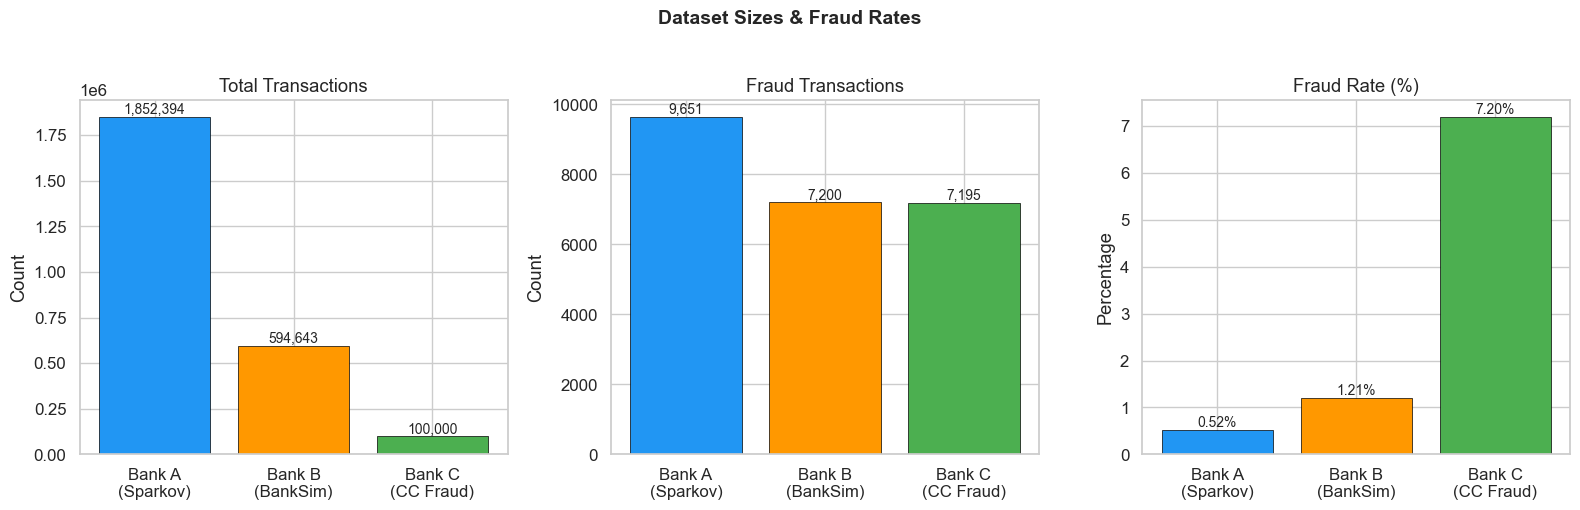

In [28]:
# ============================================================
# 5.1  Dataset sizes & fraud rates
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Total transactions ---
sizes = [len(df) for df in BANKS.values()]
bars = axes[0].bar(BANK_NAMES, sizes, color=list(COLORS.values()), edgecolor='black', linewidth=0.5)
axes[0].set_title('Total Transactions')
axes[0].set_ylabel('Count')
for bar, s in zip(bars, sizes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{s:,.0f}', ha='center', va='bottom', fontsize=10)

# --- Fraud count ---
fraud_counts = [int(df['is_fraud'].sum()) for df in BANKS.values()]
bars = axes[1].bar(BANK_NAMES, fraud_counts, color=list(COLORS.values()), edgecolor='black', linewidth=0.5)
axes[1].set_title('Fraud Transactions')
axes[1].set_ylabel('Count')
for bar, s in zip(bars, fraud_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{s:,.0f}', ha='center', va='bottom', fontsize=10)

# --- Fraud rate ---
fraud_rates = [df['is_fraud'].mean() * 100 for df in BANKS.values()]
bars = axes[2].bar(BANK_NAMES, fraud_rates, color=list(COLORS.values()), edgecolor='black', linewidth=0.5)
axes[2].set_title('Fraud Rate (%)')
axes[2].set_ylabel('Percentage')
for bar, r in zip(bars, fraud_rates):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{r:.2f}%', ha='center', va='bottom', fontsize=10)

fig.suptitle('Dataset Sizes & Fraud Rates', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(HARMONIZED / 'fig_01_size_and_fraud_rates.png', dpi=150, bbox_inches='tight')
plt.show()

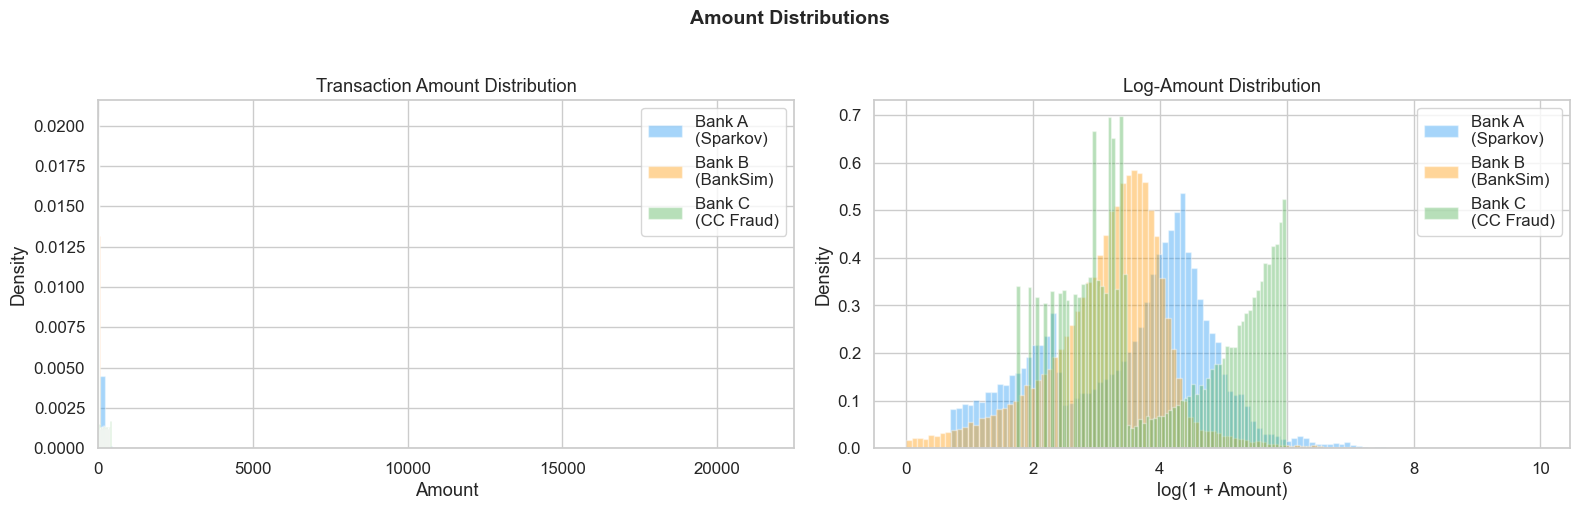

In [29]:
# ============================================================
# 5.2  Amount distributions (original scale + log scale)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for name, df in BANKS.items():
    sample = df['amount'].sample(min(50_000, len(df)), random_state=42)
    axes[0].hist(sample, bins=100, alpha=0.4, label=name, color=COLORS[name], density=True)

axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].set_xlim(0, axes[0].get_xlim()[1])

for name, df in BANKS.items():
    sample = df['log_amount'].sample(min(50_000, len(df)), random_state=42)
    axes[1].hist(sample, bins=100, alpha=0.4, label=name, color=COLORS[name], density=True)

axes[1].set_title('Log-Amount Distribution')
axes[1].set_xlabel('log(1 + Amount)')
axes[1].set_ylabel('Density')
axes[1].legend()

fig.suptitle('Amount Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(HARMONIZED / 'fig_02_amount_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

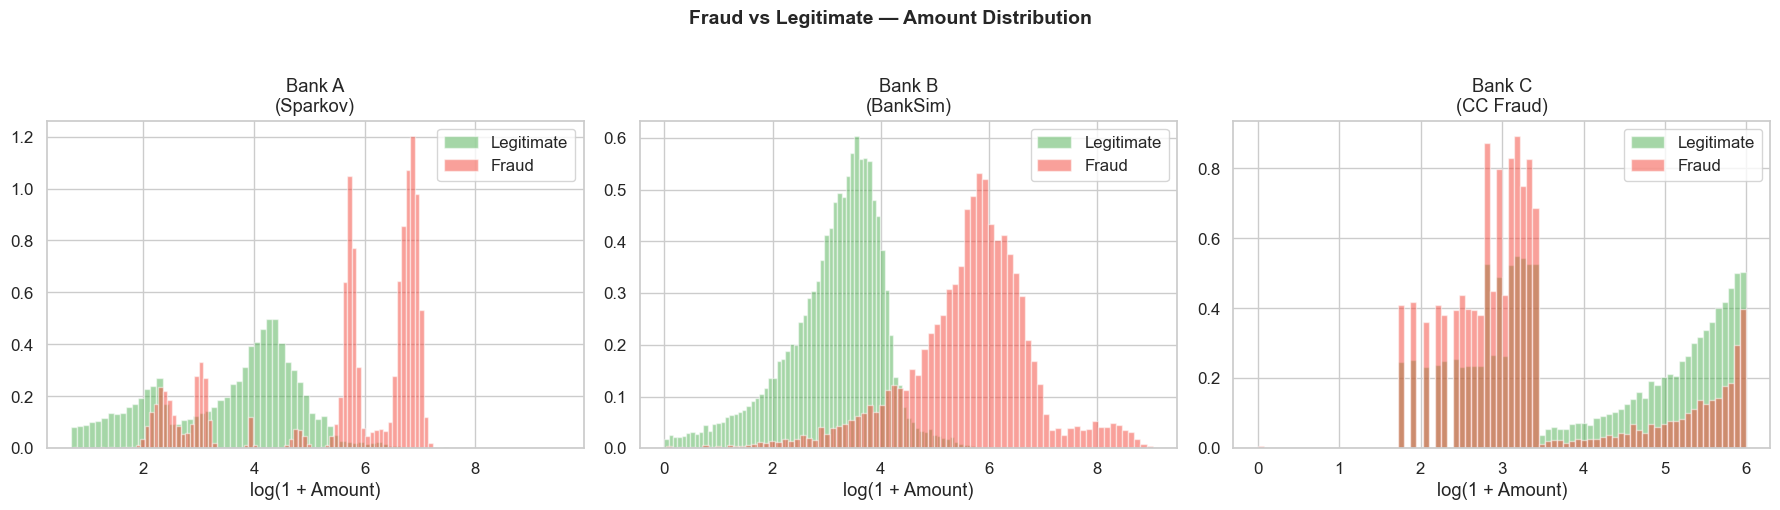

In [30]:
# ============================================================
# 5.3  Fraud vs legitimate amount distributions
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, df) in zip(axes, BANKS.items()):
    for label, color, lbl in [(0, '#4CAF50', 'Legitimate'), (1, '#F44336', 'Fraud')]:
        subset = df[df['is_fraud'] == label]['log_amount']
        sample = subset.sample(min(30_000, len(subset)), random_state=42)
        ax.hist(sample, bins=80, alpha=0.5, color=color, label=lbl, density=True)
    ax.set_title(name)
    ax.set_xlabel('log(1 + Amount)')
    ax.legend()

fig.suptitle('Fraud vs Legitimate — Amount Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(HARMONIZED / 'fig_03_fraud_vs_legit_amounts.png', dpi=150, bbox_inches='tight')
plt.show()

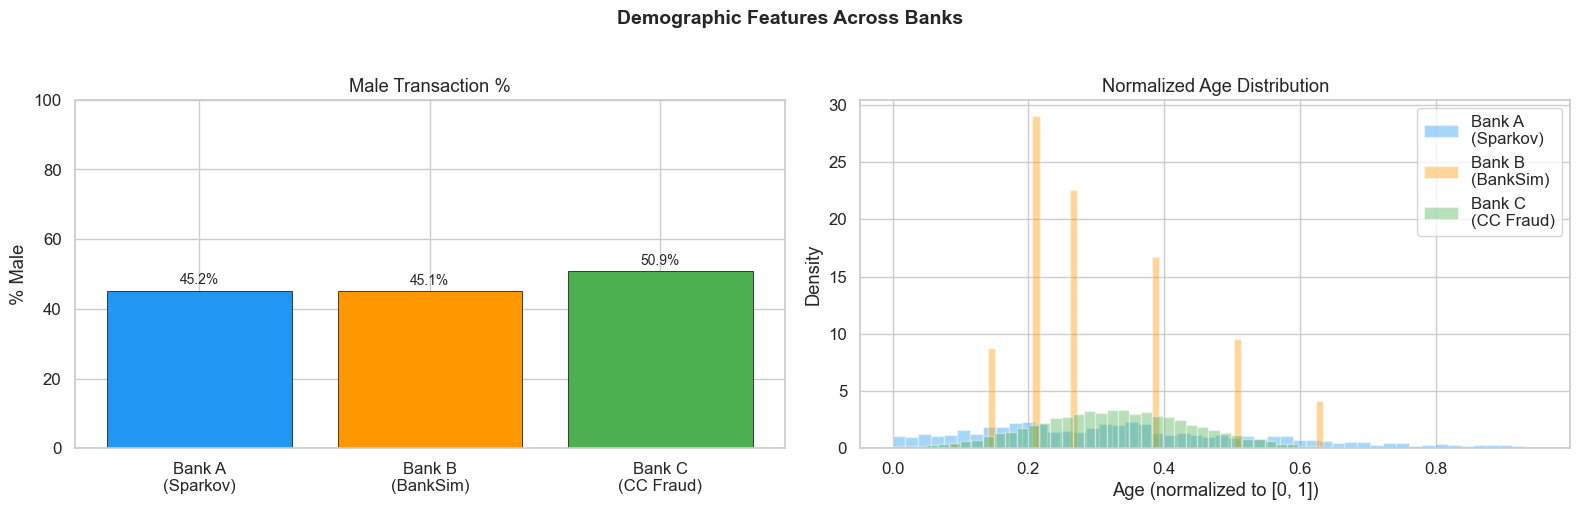

In [31]:
# ============================================================
# 5.4  Demographics: Gender and Age distributions
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gender distribution
gender_props = [df['gender_M'].mean() * 100 for df in BANKS.values()]
bars = axes[0].bar(BANK_NAMES, gender_props, color=list(COLORS.values()), edgecolor='black', linewidth=0.5)
axes[0].set_title('Male Transaction %')
axes[0].set_ylabel('% Male')
axes[0].set_ylim(0, 100)
for bar, p in zip(bars, gender_props):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{p:.1f}%', ha='center', va='bottom', fontsize=10)

# Age distribution
for name, df in BANKS.items():
    sample = df['age_normalized'].sample(min(50_000, len(df)), random_state=42)
    axes[1].hist(sample, bins=50, alpha=0.4, label=name, color=COLORS[name], density=True)
axes[1].set_title('Normalized Age Distribution')
axes[1].set_xlabel('Age (normalized to [0, 1])')
axes[1].set_ylabel('Density')
axes[1].legend()

fig.suptitle('Demographic Features Across Banks', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(HARMONIZED / 'fig_04_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

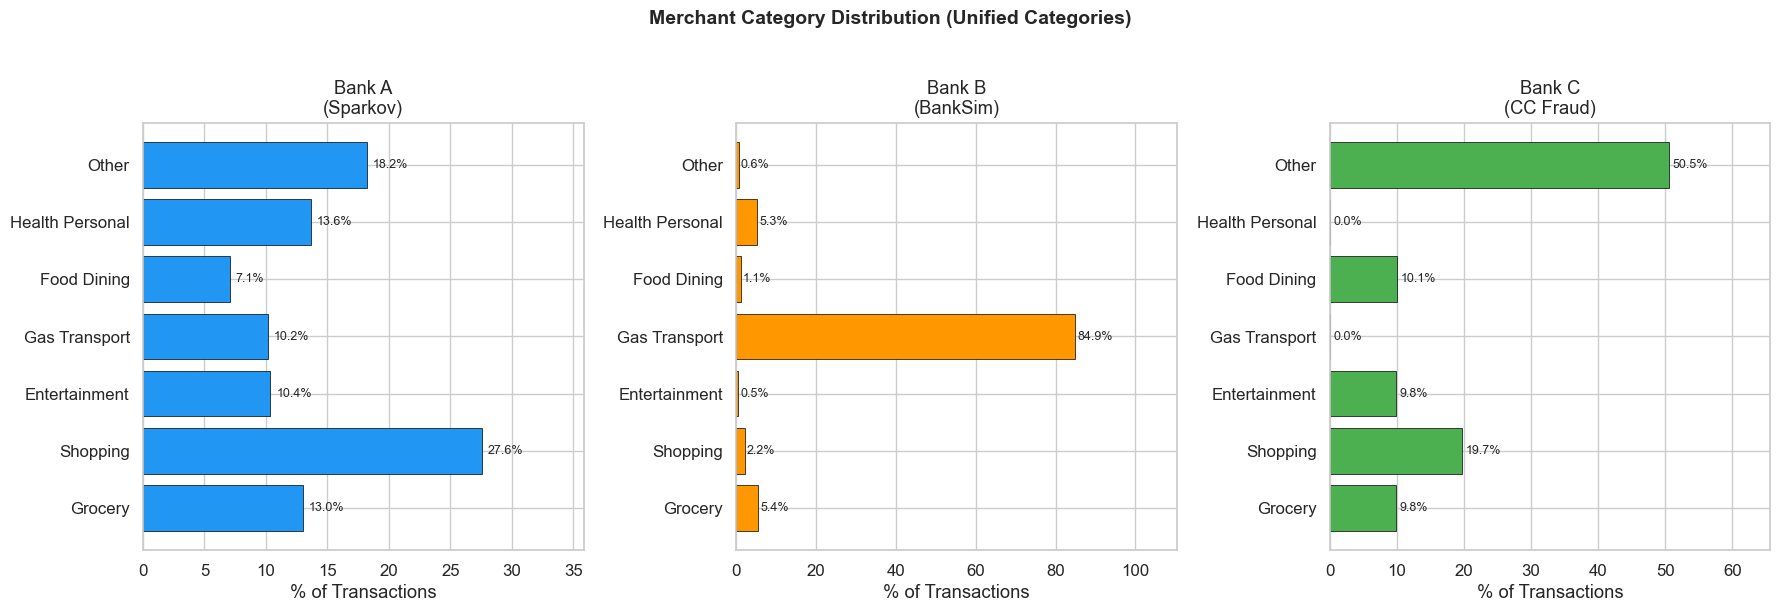

In [32]:
# ============================================================
# 5.5  Merchant category distributions (stacked bar)
# ============================================================
cat_cols = [c for c in FEATURE_ORDER if c.startswith('cat_')]
cat_labels = [c.replace('cat_', '').replace('_', ' ').title() for c in cat_cols]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, df) in zip(axes, BANKS.items()):
    proportions = [df[c].mean() * 100 for c in cat_cols]
    bars = ax.barh(cat_labels, proportions, color=COLORS[name], edgecolor='black', linewidth=0.5)
    ax.set_title(name)
    ax.set_xlabel('% of Transactions')
    ax.set_xlim(0, max(proportions) * 1.3)
    for bar, p in zip(bars, proportions):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{p:.1f}%', ha='left', va='center', fontsize=9)

fig.suptitle('Merchant Category Distribution (Unified Categories)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(HARMONIZED / 'fig_05_category_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

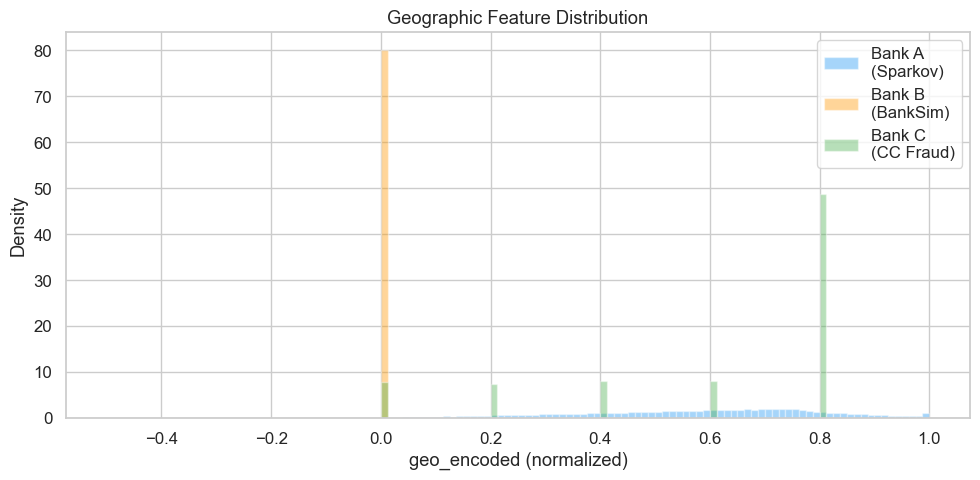

In [33]:
# ============================================================
# 5.6  Geographic feature distribution
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))

for name, df in BANKS.items():
    sample = df['geo_encoded'].sample(min(50_000, len(df)), random_state=42)
    ax.hist(sample, bins=80, alpha=0.4, label=name, color=COLORS[name], density=True)

ax.set_title('Geographic Feature Distribution')
ax.set_xlabel('geo_encoded (normalized)')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
fig.savefig(HARMONIZED / 'fig_06_geographic_feature.png', dpi=150, bbox_inches='tight')
plt.show()

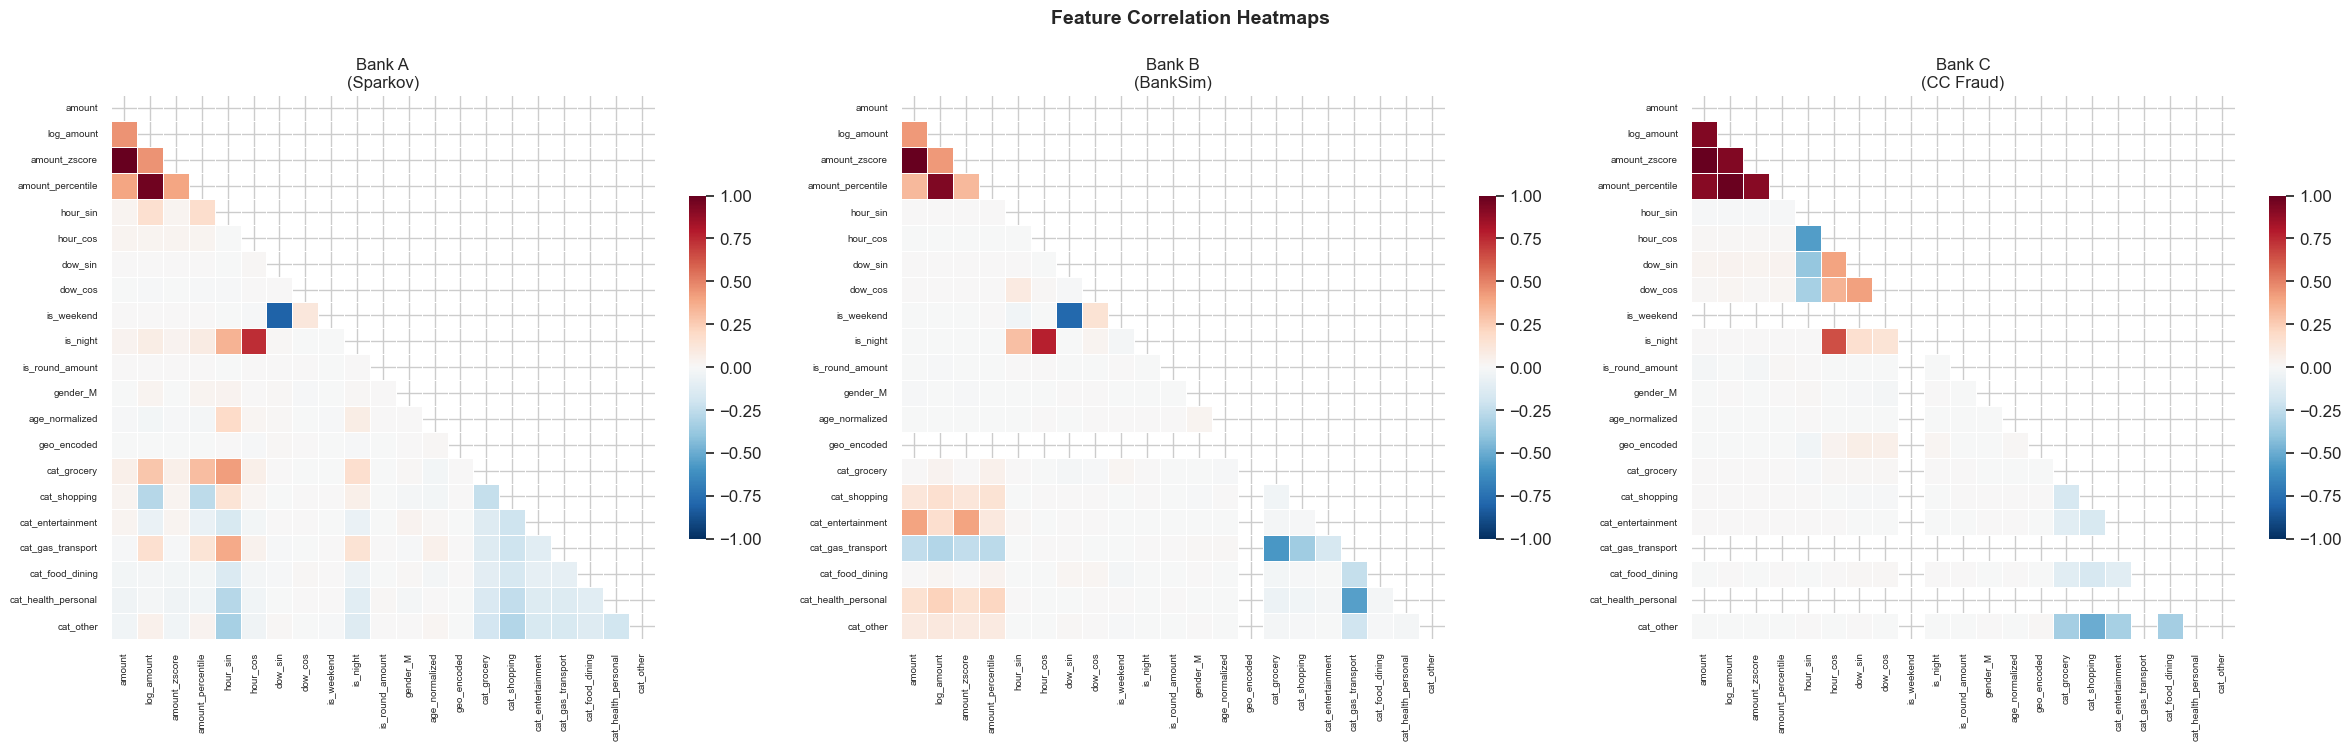

In [34]:
# ============================================================
# 5.7  Feature correlation heatmaps per bank
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, (name, df) in zip(axes, BANKS.items()):
    corr = df[FEATURE_ORDER[:-1]].sample(min(50_000, len(df)), random_state=42).corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                square=True, linewidths=0.5, cbar_kws={'shrink': 0.6},
                xticklabels=True, yticklabels=True)
    ax.set_title(name, fontsize=12)
    ax.tick_params(axis='both', labelsize=7)

fig.suptitle('Feature Correlation Heatmaps', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(HARMONIZED / 'fig_07_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

c:\Users\Silbar\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Silbar\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


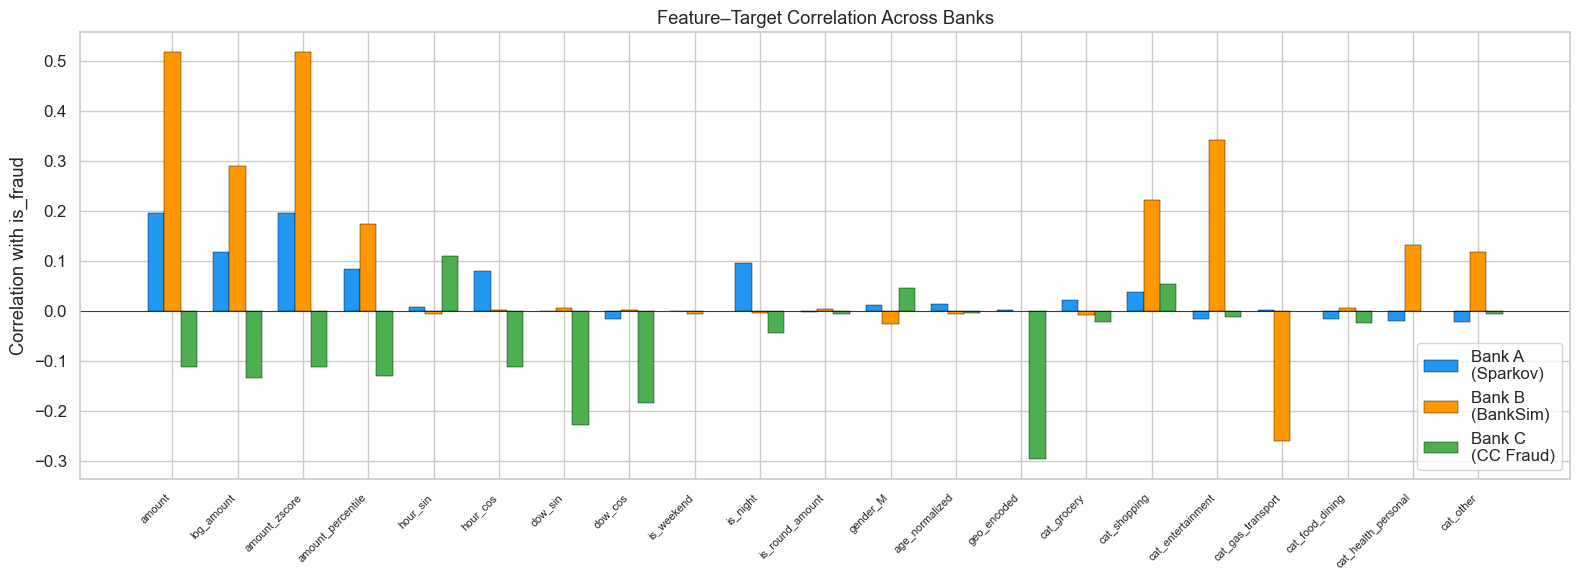

In [35]:
# ============================================================
# 5.8  Feature-target correlation (which features predict fraud?)
# ============================================================
fig, ax = plt.subplots(figsize=(16, 6))

features = FEATURE_ORDER[:-1]
x = np.arange(len(features))
width = 0.25

for i, (name, df) in enumerate(BANKS.items()):
    sample = df.sample(min(50_000, len(df)), random_state=42)
    correlations = [sample[feat].corr(sample['is_fraud']) for feat in features]
    ax.bar(x + i * width, correlations, width, label=name, color=COLORS[name],
           edgecolor='black', linewidth=0.3)

ax.set_xticks(x + width)
ax.set_xticklabels(features, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Correlation with is_fraud')
ax.set_title('Feature–Target Correlation Across Banks')
ax.legend()
ax.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
fig.savefig(HARMONIZED / 'fig_08_feature_target_corr.png', dpi=150, bbox_inches='tight')
plt.show()

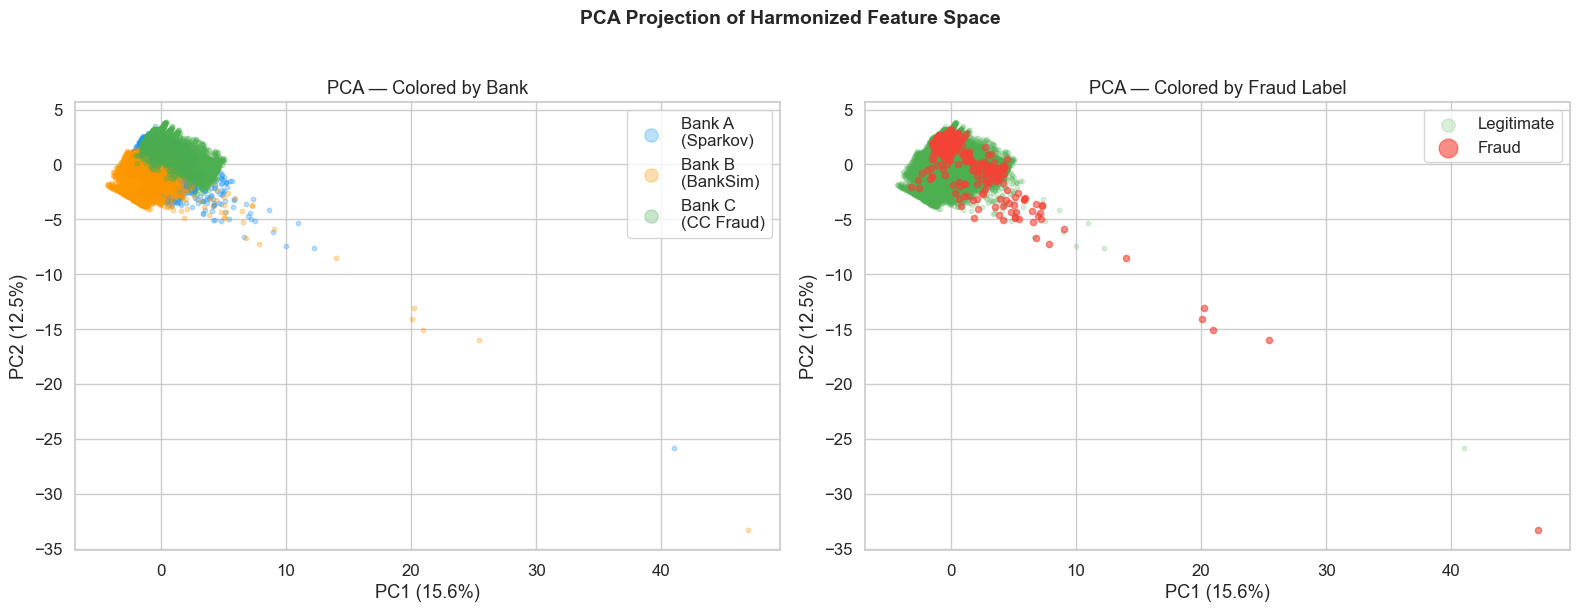

In [36]:
# ============================================================
# 5.9  PCA projection — do harmonized datasets occupy a similar space?
# ============================================================
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

N_SAMPLE = 5_000
samples = []
bank_labels = []
fraud_labels = []

for name, df in BANKS.items():
    s = df.sample(min(N_SAMPLE, len(df)), random_state=42)
    samples.append(s[FEATURE_ORDER[:-1]])
    bank_labels.extend([name] * len(s))
    fraud_labels.extend(s['is_fraud'].tolist())

combined = pd.concat(samples, ignore_index=True)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(combined)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Color by bank
for name in BANK_NAMES:
    mask = [b == name for b in bank_labels]
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.3, s=10,
                    color=COLORS[name], label=name)
axes[0].set_title('PCA — Colored by Bank')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].legend(markerscale=3)

# Color by fraud
fraud_arr = np.array(fraud_labels)
axes[1].scatter(X_pca[fraud_arr == 0, 0], X_pca[fraud_arr == 0, 1],
                alpha=0.2, s=10, color='#4CAF50', label='Legitimate')
axes[1].scatter(X_pca[fraud_arr == 1, 0], X_pca[fraud_arr == 1, 1],
                alpha=0.6, s=20, color='#F44336', label='Fraud')
axes[1].set_title('PCA — Colored by Fraud Label')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[1].legend(markerscale=3)

fig.suptitle('PCA Projection of Harmonized Feature Space', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(HARMONIZED / 'fig_09_pca_projection.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
# ============================================================
# 5.10  KS test — statistical divergence between banks
# ============================================================
from scipy.stats import ks_2samp

print('Kolmogorov-Smirnov test p-values (per feature, between bank pairs):')
print('Low p-value = distributions are significantly different\n')

pairs = [('A vs B', bank_a, bank_b), ('A vs C', bank_a, bank_c), ('B vs C', bank_b, bank_c)]
ks_results = {}

for pair_name, df1, df2 in pairs:
    ks_results[pair_name] = {}
    s1 = df1.sample(min(10_000, len(df1)), random_state=42)
    s2 = df2.sample(min(10_000, len(df2)), random_state=42)
    for feat in FEATURE_ORDER[:-1]:
        stat, pval = ks_2samp(s1[feat], s2[feat])
        ks_results[pair_name][feat] = (stat, pval)

ks_df = pd.DataFrame({
    pair: {feat: f'{stat:.3f} (p={pval:.1e})' for feat, (stat, pval) in feats.items()}
    for pair, feats in ks_results.items()
})
display(ks_df)

Kolmogorov-Smirnov test p-values (per feature, between bank pairs):
Low p-value = distributions are significantly different



c:\Users\Silbar\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


,A vs B,A vs C,B vs C
amount,0.302 (p=9.9e-324),0.250 (p=9.6e-275),0.369 (p=0.0e+00)
log_amount,0.302 (p=9.9e-324),0.250 (p=9.6e-275),0.369 (p=0.0e+00)
amount_zscore,0.311 (p=9.9e-324),0.561 (p=0.0e+00),0.573 (p=0.0e+00)
amount_percentile,0.018 (p=9.4e-02),0.028 (p=6.6e-04),0.018 (p=9.4e-02)
hour_sin,0.143 (p=3.7e-89),0.237 (p=9.7e-248),0.370 (p=0.0e+00)
hour_cos,0.033 (p=4.8e-05),0.280 (p=9.9e-324),0.309 (p=9.9e-324)
dow_sin,0.032 (p=8.6e-05),0.641 (p=0.0e+00),0.619 (p=0.0e+00)
dow_cos,0.091 (p=1.9e-36),0.208 (p=2.5e-189),0.222 (p=1.8e-215)
is_weekend,0.031 (p=1.2e-04),0.324 (p=9.9e-324),0.293 (p=9.9e-324)
is_night,0.057 (p=2.1e-14),0.182 (p=1.9e-144),0.238 (p=2.0e-249)


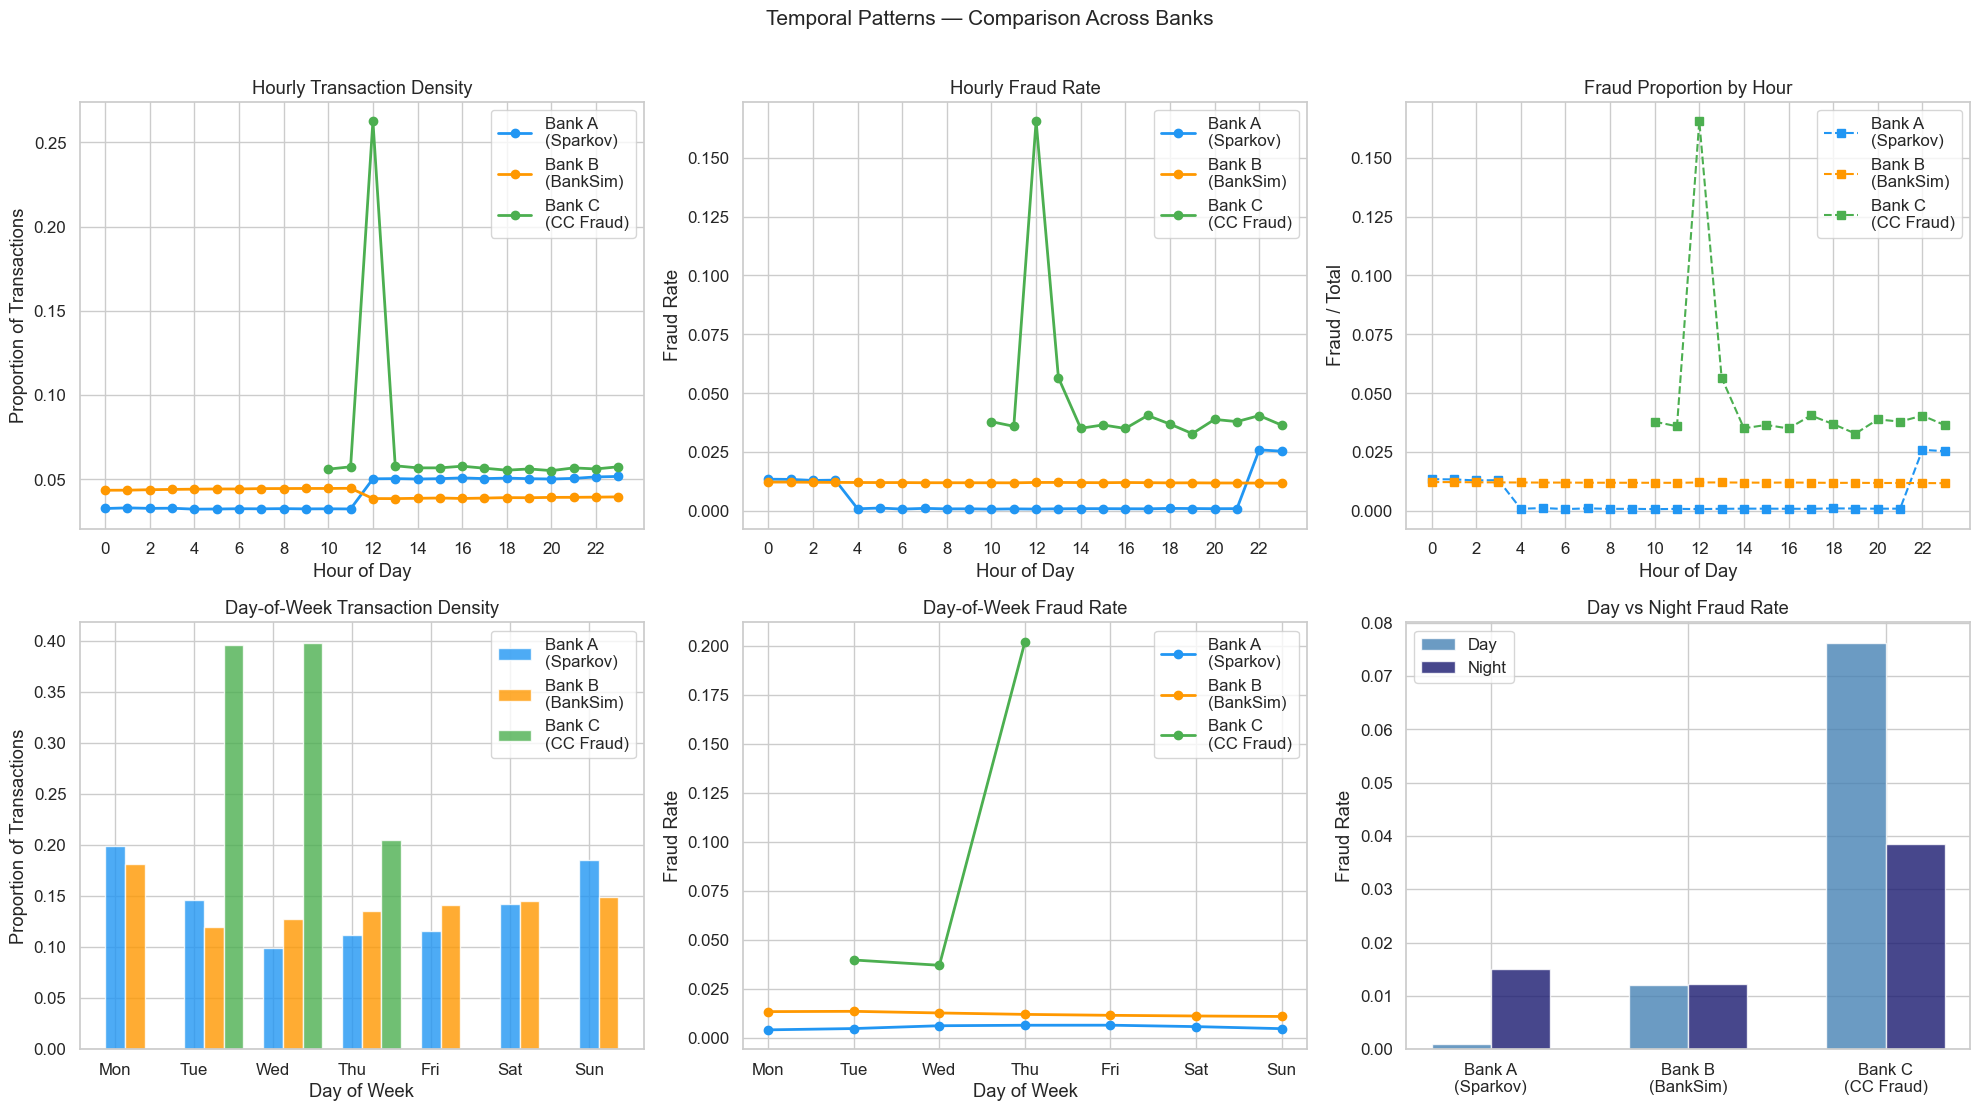


Temporal Summary per Bank:

Bank A
(Sparkov):
  Peak transaction hour: 23:00
  Peak fraud-rate hour:  22:00
  Weekend fraud rate:    0.5080%  vs  Weekday: 0.5273%
  Night fraud rate:      1.4972%  vs  Day:     0.1034%

Bank B
(BankSim):
  Peak transaction hour: 11:00
  Peak fraud-rate hour:  0:00
  Weekend fraud rate:    1.0974%  vs  Weekday: 1.2581%
  Night fraud rate:      1.2165%  vs  Day:     1.2078%

Bank C
(CC Fraud):
  Peak transaction hour: 12:00
  Peak fraud-rate hour:  12:00
  Weekend fraud rate:    nan%  vs  Weekday: 7.1950%
  Night fraud rate:      3.8516%  vs  Day:     7.6240%


In [40]:
# ============================================================
# 5.11  Time comparison across banks
# ============================================================

# Reconstruct hour_of_day and day_of_week from trig features
# hour = atan2(hour_sin, hour_cos) * 24 / (2*pi), rounded to nearest int
for _label, _df in BANKS.items():
    _df['hour_of_day'] = (np.arctan2(_df['hour_sin'], _df['hour_cos']) * 24 / (2 * np.pi)).round().astype(int) % 24
    _df['day_of_week'] = (np.arctan2(_df['dow_sin'], _df['dow_cos']) * 7 / (2 * np.pi)).round().astype(int) % 7

fig, axes = plt.subplots(2, 3, figsize=(20, 11))

banks = list(BANKS.items())
BANK_COLORS = COLORS

# --- Row 1: Hourly patterns ---

# 1a. Overall hourly transaction density
ax = axes[0, 0]
for label, df in banks:
    counts = df['hour_of_day'].value_counts().sort_index()
    counts_norm = counts / counts.sum()
    ax.plot(counts_norm.index, counts_norm.values, 'o-', label=label, color=BANK_COLORS[label], linewidth=2)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Proportion of Transactions')
ax.set_title('Hourly Transaction Density')
ax.legend()
ax.set_xticks(range(0, 24, 2))

# 1b. Hourly fraud rate per bank
ax = axes[0, 1]
for label, df in banks:
    hourly_fraud = df.groupby('hour_of_day')['is_fraud'].mean()
    ax.plot(hourly_fraud.index, hourly_fraud.values, 'o-', label=label, color=BANK_COLORS[label], linewidth=2)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Fraud Rate')
ax.set_title('Hourly Fraud Rate')
ax.legend()
ax.set_xticks(range(0, 24, 2))

# 1c. Hourly fraud vs legitimate count (stacked, all banks combined)
ax = axes[0, 2]
for label, df in banks:
    fraud_hourly = df[df['is_fraud'] == 1]['hour_of_day'].value_counts().sort_index()
    legit_hourly = df[df['is_fraud'] == 0]['hour_of_day'].value_counts().sort_index()
    fraud_ratio = fraud_hourly / (fraud_hourly + legit_hourly)
    ax.plot(fraud_ratio.index, fraud_ratio.values, 's--', label=f'{label}', color=BANK_COLORS[label], linewidth=1.5)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Fraud / Total')
ax.set_title('Fraud Proportion by Hour')
ax.legend()
ax.set_xticks(range(0, 24, 2))

# --- Row 2: Day-of-week patterns ---

dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# 2a. Day-of-week transaction density
ax = axes[1, 0]
width = 0.25
for i, (label, df) in enumerate(banks):
    counts = df['day_of_week'].value_counts().sort_index()
    counts_norm = counts / counts.sum()
    ax.bar(counts_norm.index + i * width, counts_norm.values, width=width,
           label=label, color=BANK_COLORS[label], alpha=0.8)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Proportion of Transactions')
ax.set_title('Day-of-Week Transaction Density')
ax.set_xticks(range(7))
ax.set_xticklabels(dow_labels)
ax.legend()

# 2b. Day-of-week fraud rate per bank
ax = axes[1, 1]
for label, df in banks:
    dow_fraud = df.groupby('day_of_week')['is_fraud'].mean()
    ax.plot(dow_fraud.index, dow_fraud.values, 'o-', label=label, color=BANK_COLORS[label], linewidth=2)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Fraud Rate')
ax.set_title('Day-of-Week Fraud Rate')
ax.set_xticks(range(7))
ax.set_xticklabels(dow_labels)
ax.legend()

# 2c. Night vs day fraud rate comparison
ax = axes[1, 2]
x_pos = np.arange(len(banks))
night_rates = []
day_rates = []
labels_list = []
for label, df in banks:
    night_rates.append(df[df['is_night'] == 1]['is_fraud'].mean())
    day_rates.append(df[df['is_night'] == 0]['is_fraud'].mean())
    labels_list.append(label)

ax.bar(x_pos - 0.15, day_rates, 0.3, label='Day', color='steelblue', alpha=0.8)
ax.bar(x_pos + 0.15, night_rates, 0.3, label='Night', color='midnightblue', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(labels_list)
ax.set_ylabel('Fraud Rate')
ax.set_title('Day vs Night Fraud Rate')
ax.legend()

plt.suptitle('Temporal Patterns — Comparison Across Banks', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(HARMONIZED / 'fig_14_temporal_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Summary statistics ---
print('\nTemporal Summary per Bank:')
print('=' * 65)
for label, df in banks:
    peak_hour = df['hour_of_day'].mode()[0]
    peak_fraud_hour = df.groupby('hour_of_day')['is_fraud'].mean().idxmax()
    weekend_rate = df[df['is_weekend'] == 1]['is_fraud'].mean()
    weekday_rate = df[df['is_weekend'] == 0]['is_fraud'].mean()
    night_rate = df[df['is_night'] == 1]['is_fraud'].mean()
    day_rate = df[df['is_night'] == 0]['is_fraud'].mean()
    print(f'\n{label}:')
    print(f'  Peak transaction hour: {int(peak_hour)}:00')
    print(f'  Peak fraud-rate hour:  {int(peak_fraud_hour)}:00')
    print(f'  Weekend fraud rate:    {weekend_rate:.4%}  vs  Weekday: {weekday_rate:.4%}')
    print(f'  Night fraud rate:      {night_rate:.4%}  vs  Day:     {day_rate:.4%}')

---
## 6. Challenges & Resolutions

### Challenge 1: Size imbalance
Sparkov (~1.85M) is much larger than BankSim (~594K) and CC Fraud (~100K). We subsample Sparkov to bring sizes closer.

### Challenge 2: Class imbalance
All banks have fraud rates well below 5%. We preserve fraud rates during subsampling and note that class-weighted loss / oversampling will be needed during training.

### Challenge 3: Feature heterogeneity in geo_encoded
Each bank encodes geography differently (lat/lon distance vs zip code distance vs country label). The model must learn that `geo_encoded` has bank-specific semantics — this is realistic for federated settings.

In [ ]:
# ============================================================
# 6.1  Subsample Sparkov to reduce size imbalance
# ============================================================
SPARKOV_TARGET_SIZE = 500_000

print(f'Bank A (Sparkov) before subsampling: {len(bank_a):,} rows, fraud rate {bank_a["is_fraud"].mean():.4%}')

fraud_a   = bank_a[bank_a['is_fraud'] == 1]
legit_a   = bank_a[bank_a['is_fraud'] == 0]
fraud_rate_a = len(fraud_a) / len(bank_a)

n_fraud_a = int(SPARKOV_TARGET_SIZE * fraud_rate_a)
n_legit_a = SPARKOV_TARGET_SIZE - n_fraud_a

bank_a_sampled = pd.concat([
    fraud_a.sample(n=min(n_fraud_a, len(fraud_a)), random_state=42),
    legit_a.sample(n=min(n_legit_a, len(legit_a)), random_state=42)
], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Bank A after subsampling:  {len(bank_a_sampled):,} rows, fraud rate {bank_a_sampled["is_fraud"].mean():.4%}')
print(f'Bank B (BankSim):          {len(bank_b):,} rows, fraud rate {bank_b["is_fraud"].mean():.4%}')
print(f'Bank C (CC Fraud):         {len(bank_c):,} rows, fraud rate {bank_c["is_fraud"].mean():.4%}')

Bank A (Sparkov) before subsampling: 1,852,394 rows, fraud rate 0.5210%
Bank A after subsampling:  500,000 rows, fraud rate 0.5210%
Bank B (BankSim):          594,643 rows, fraud rate 1.2108%
Bank C (CC Fraud):         100,000 rows, fraud rate 7.1950%


In [ ]:
# ============================================================
# 6.2  Build local-model feature sets (rich private features)
# ============================================================

# Bank A (Sparkov): private features — merchant lat/lon, city_pop, job category, state
def build_local_sparkov(raw_df, harmonized_df):
    loc = harmonized_df.copy()
    loc['merch_lat']       = raw_df['merch_lat'].values[:len(loc)]
    loc['merch_long']      = raw_df['merch_long'].values[:len(loc)]
    loc['card_lat']        = raw_df['lat'].values[:len(loc)]
    loc['card_long']       = raw_df['long'].values[:len(loc)]
    loc['city_pop_log']    = np.log1p(raw_df['city_pop'].values[:len(loc)])
    # State one-hot (top 10 states, rest as 'other')
    states = raw_df['state'].values[:len(loc)]
    top_states = pd.Series(states).value_counts().head(10).index.tolist()
    for st in top_states:
        loc[f'state_{st}'] = (states == st).astype(np.int8)
    return loc

# Bank B (BankSim): private features — customer/merchant zip codes, customer ID frequency
def build_local_banksim(raw_df, harmonized_df):
    loc = harmonized_df.copy()
    # Customer transaction frequency
    cust_freq = raw_df['customer'].map(raw_df['customer'].value_counts())
    loc['customer_tx_freq'] = np.log1p(cust_freq.values)
    # Merchant transaction frequency
    merch_freq = raw_df['merchant'].map(raw_df['merchant'].value_counts())
    loc['merchant_tx_freq'] = np.log1p(merch_freq.values)
    return loc

# Bank C (CC Fraud): private features — card type, entry mode, transaction type
def build_local_ccfraud(raw_df, harmonized_df):
    loc = harmonized_df.copy()
    # One-hot encode card type, entry mode, transaction type if available
    for col_name, prefix in [('Type of Card', 'card'), ('Entry Mode', 'entry'),
                              ('Type of Transaction', 'txtype')]:
        if col_name in raw_df.columns:
            for val in raw_df[col_name].dropna().unique():
                loc[f'{prefix}_{str(val).strip().lower().replace(" ", "_")}'] = \
                    (raw_df[col_name].astype(str).str.strip() == str(val).strip()).astype(np.int8)
    return loc

# Build local datasets using sampled bank_a
local_a = build_local_sparkov(sparkov.sample(n=len(bank_a_sampled), random_state=42).reset_index(drop=True), bank_a_sampled)
local_b = build_local_banksim(banksim, bank_b)
local_c = build_local_ccfraud(ccfraud, bank_c)

print('Local feature sets:')
for name, df in [('Bank A', local_a), ('Bank B', local_b), ('Bank C', local_c)]:
    feats = [c for c in df.columns if c != 'is_fraud']
    print(f'  {name}: {len(feats)} features + label ({df.shape[0]:,} rows)')
    print(f'    Extra private features: {[c for c in feats if c not in FEATURE_ORDER]}')

Local feature sets:
  Bank A: 36 features + label (500,000 rows)
    Extra private features: ['merch_lat', 'merch_long', 'card_lat', 'card_long', 'city_pop_log', 'state_TX', 'state_NY', 'state_PA', 'state_CA', 'state_MI', 'state_OH', 'state_IL', 'state_FL', 'state_AL', 'state_MO']
  Bank B: 23 features + label (594,643 rows)
    Extra private features: ['customer_tx_freq', 'merchant_tx_freq']
  Bank C: 29 features + label (100,000 rows)
    Extra private features: ['card_visa', 'card_mastercard', 'entry_tap', 'entry_pin', 'entry_cvc', 'txtype_pos', 'txtype_online', 'txtype_atm']


---
## 7. Save Harmonized & Local Datasets

In [ ]:
# ============================================================
# 7.1  Save harmonized (federated) datasets
# ============================================================
bank_a_sampled.to_csv(HARMONIZED / 'bank_a_sparkov.csv', index=False)
bank_b.to_csv(HARMONIZED / 'bank_b_banksim.csv', index=False)
bank_c.to_csv(HARMONIZED / 'bank_c_ccfraud.csv', index=False)

print('Harmonized (federated) datasets saved to data/harmonized_v2/:')
for name, fname, df in [('Bank A', 'bank_a_sparkov.csv', bank_a_sampled),
                         ('Bank B', 'bank_b_banksim.csv', bank_b),
                         ('Bank C', 'bank_c_ccfraud.csv', bank_c)]:
    fsize = (HARMONIZED / fname).stat().st_size / 1e6
    print(f'  {name}: {fname}  ({df.shape[0]:,} rows × {df.shape[1]} cols, {fsize:.1f} MB)')

Harmonized (federated) datasets saved to data/harmonized_v2/:
  Bank A: bank_a_sparkov.csv  (500,000 rows × 22 cols, 98.3 MB)
  Bank B: bank_b_banksim.csv  (594,643 rows × 22 cols, 108.3 MB)
  Bank C: bank_c_ccfraud.csv  (100,000 rows × 22 cols, 18.3 MB)


In [ ]:
# ============================================================
# 7.2  Save local-model datasets
# ============================================================
local_a.to_csv(LOCAL / 'bank_a_sparkov_local.csv', index=False)
local_b.to_csv(LOCAL / 'bank_b_banksim_local.csv', index=False)
local_c.to_csv(LOCAL / 'bank_c_ccfraud_local.csv', index=False)

print('Local-model datasets saved to data/local_v2/:')
for name, fname, df in [('Bank A', 'bank_a_sparkov_local.csv', local_a),
                         ('Bank B', 'bank_b_banksim_local.csv', local_b),
                         ('Bank C', 'bank_c_ccfraud_local.csv', local_c)]:
    fsize = (LOCAL / fname).stat().st_size / 1e6
    print(f'  {name}: {fname}  ({df.shape[0]:,} rows × {df.shape[1]} cols, {fsize:.1f} MB)')

Local-model datasets saved to data/local_v2/:
  Bank A: bank_a_sparkov_local.csv  (500,000 rows × 37 cols, 137.3 MB)
  Bank B: bank_b_banksim_local.csv  (594,643 rows × 24 cols, 130.2 MB)
  Bank C: bank_c_ccfraud_local.csv  (100,000 rows × 30 cols, 19.9 MB)


---
## 8. Final Summary

### Output files

**`data/harmonized_v2/`** — Federated model datasets (21-feature common schema)
- `bank_a_sparkov.csv` — subsampled Sparkov
- `bank_b_banksim.csv` — full BankSim
- `bank_c_ccfraud.csv` — full CC Fraud

**`data/local_v2/`** — Local model datasets (common features + bank-specific private features)
- `bank_a_sparkov_local.csv` — +lat/lon, city_pop, state one-hots
- `bank_b_banksim_local.csv` — +customer/merchant transaction frequency
- `bank_c_ccfraud_local.csv` — +card type, entry mode, transaction type

In [ ]:
# ============================================================
# Final validation
# ============================================================
print('=== FINAL VALIDATION ===\n')

for name, df, label_col in [('Bank A (Sparkov)', bank_a_sampled, 'is_fraud'),
                              ('Bank B (BankSim)', bank_b, 'is_fraud'),
                              ('Bank C (CC Fraud)', bank_c, 'is_fraud')]:
    features = [c for c in df.columns if c != label_col]
    print(f'{name}:')
    print(f'  Rows:          {len(df):>10,}')
    print(f'  Features:      {len(features):>10}')
    print(f'  Nulls:         {df.isnull().sum().sum():>10}')
    print(f'  Fraud count:   {int(df[label_col].sum()):>10,}')
    print(f'  Fraud rate:    {df[label_col].mean():>10.4%}')
    print(f'  Dtypes:        {dict(df.dtypes.value_counts())}')
    print()

# Verify schema consistency
assert list(bank_a_sampled.columns) == list(bank_b.columns) == list(bank_c.columns) == FEATURE_ORDER
print('All three banks have identical 22-column schema (21 features + 1 label).')
print('Notebook complete.')

=== FINAL VALIDATION ===

Bank A (Sparkov):
  Rows:             500,000
  Features:              21
  Nulls:                  0
  Fraud count:        2,605
  Fraud rate:       0.5210%
  Dtypes:        {dtype('int8'): np.int64(12), dtype('float64'): np.int64(10)}

Bank B (BankSim):
  Rows:             594,643
  Features:              21
  Nulls:                  0
  Fraud count:        7,200
  Fraud rate:       1.2108%
  Dtypes:        {dtype('int8'): np.int64(12), dtype('float64'): np.int64(10)}

Bank C (CC Fraud):
  Rows:             100,000
  Features:              21
  Nulls:                  0
  Fraud count:        7,195
  Fraud rate:       7.1950%
  Dtypes:        {dtype('int8'): np.int64(12), dtype('float64'): np.int64(10)}

All three banks have identical 22-column schema (21 features + 1 label).
Notebook complete.


---
## 9. Data Exploration — Adults Profile Dataset

Exploratory analysis of the `adults_2550_female_urban_20-39.csv` dataset to assess diversity, distributions, and patterns.

Shape: (3294, 26)

Column dtypes:
ssn            object
cc_num          int64
first          object
last           object
gender         object
street         object
city           object
state          object
zip             int64
lat           float64
long          float64
city_pop        int64
job            object
dob            object
acct_num        int64
profile        object
trans_num      object
trans_date     object
trans_time     object
unix_time       int64
category       object
amt           float64
is_fraud        int64
merchant       object
merch_lat     float64
merch_long    float64
dtype: object

Missing values:
Series([], dtype: int64)

Unique cardholders (by SSN): 3
Unique credit cards:         3
Date range:                  2025-01-01 → 2025-12-31

Fraud rate: 1.0018%  (33 fraud / 3294 total)


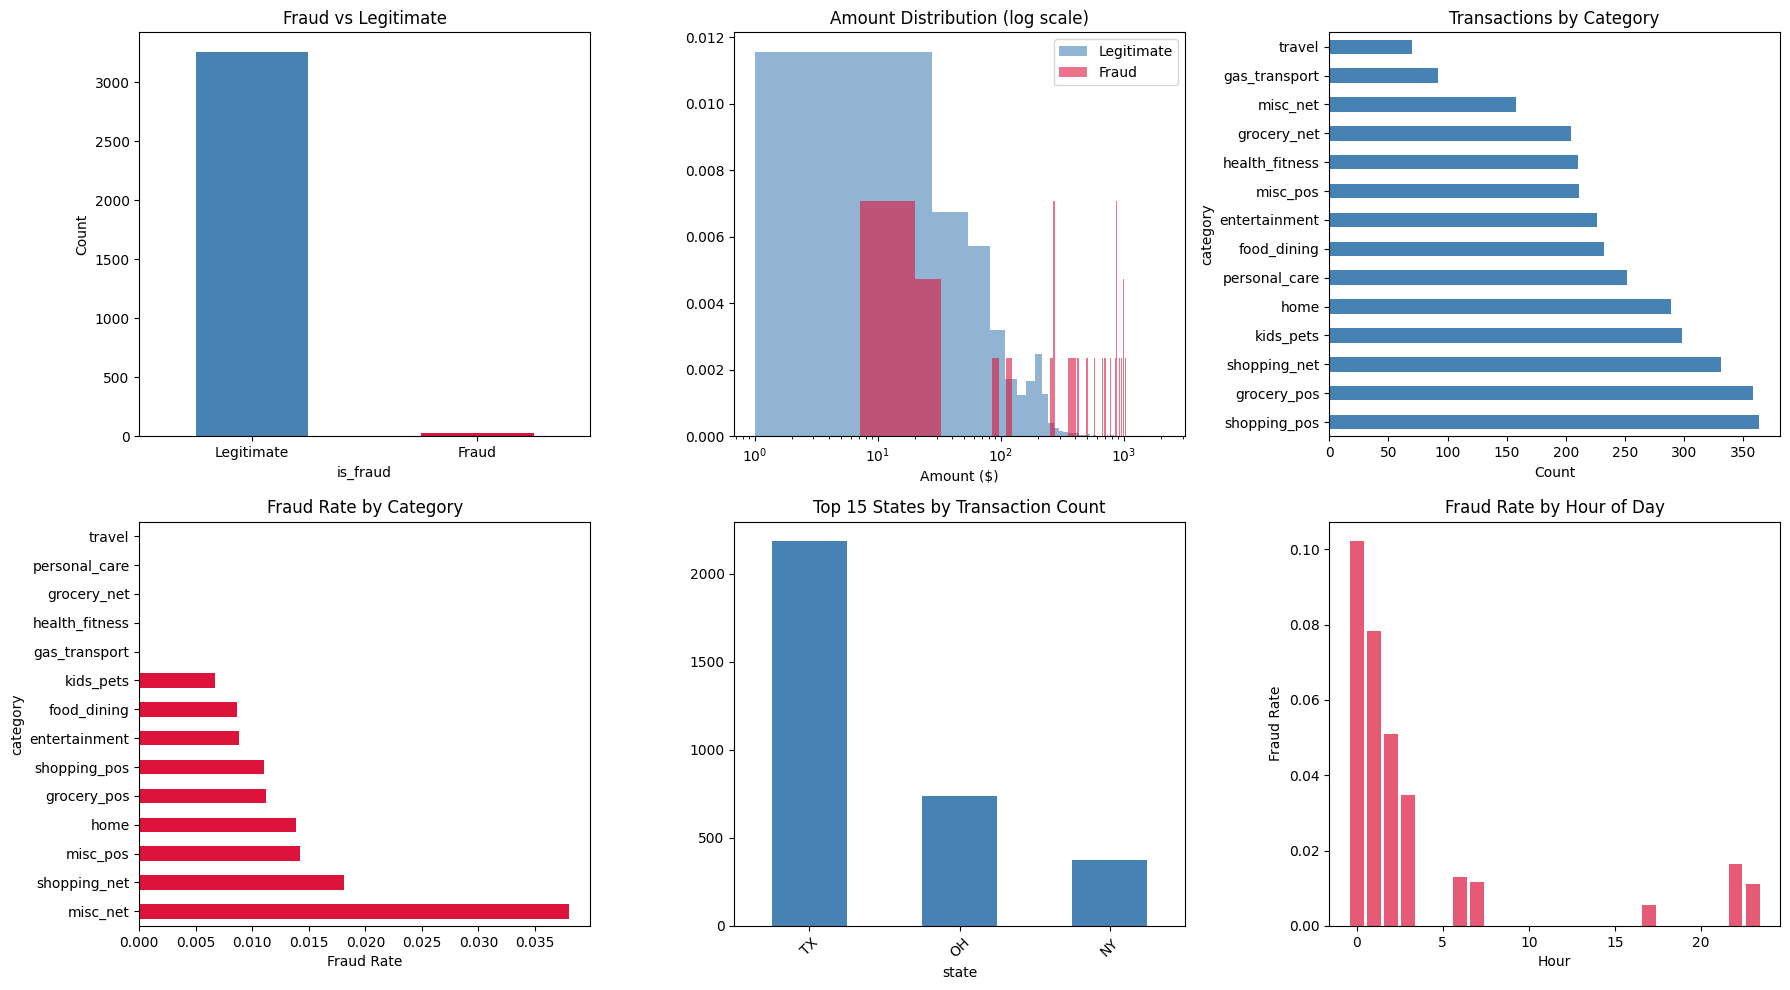


DIVERSITY ASSESSMENT

Age range: 27 – 40
Age distribution:
age
27     738
32     371
40    2185

Unique states:      3
Unique cities:      3
Unique jobs:        3
Unique categories:  14
Unique merchants:   669

City population stats:
count    3.294000e+03
mean     8.406918e+05
std      5.933152e+05
min      7.646000e+03
25%      8.732000e+03
50%      1.263321e+06
75%      1.263321e+06
max      1.263321e+06

Amount stats — Legitimate:
count    3261.000000
mean       90.493471
std       121.583361
min         1.000000
25%        19.520000
50%        56.310000
75%       119.270000
max      2133.430000

Amount stats — Fraud:
count      33.000000
mean      530.637879
std       357.703549
min         7.200000
25%       264.790000
50%       497.040000
75%       868.700000
max      1033.250000


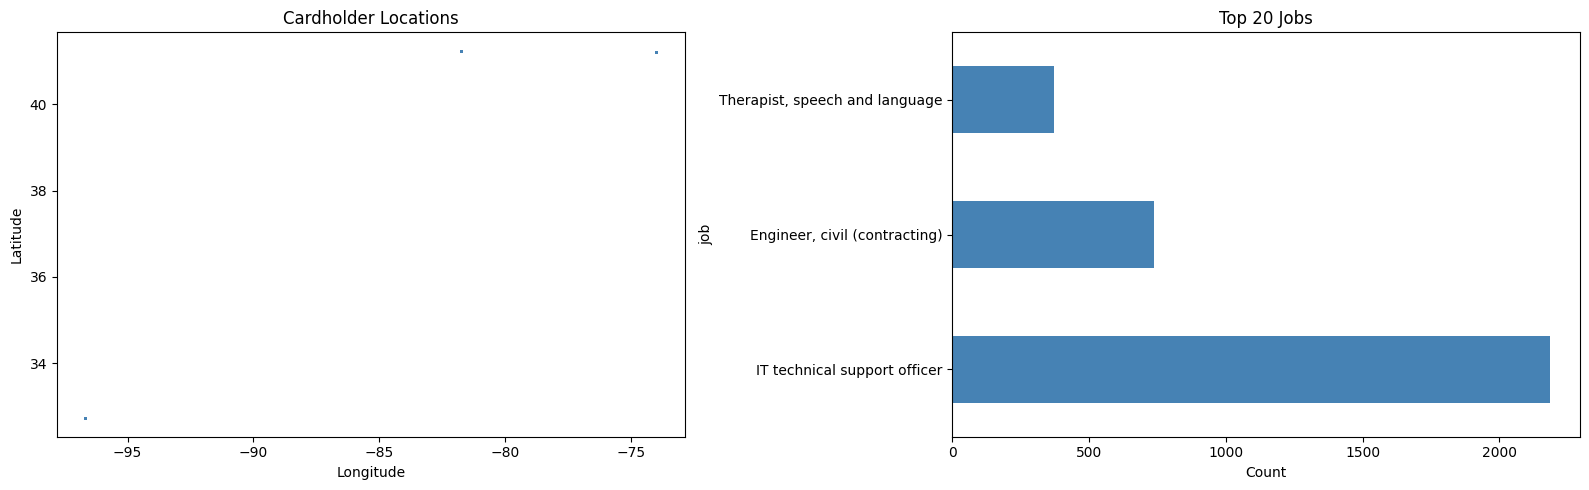

In [ ]:
# ============================================================
# 9. Data Exploration — adults_2550_female_urban_20-39.csv
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_ROOT = Path('data')
adults = pd.read_csv(DATA_ROOT / 'adults_2550_female_urban_20-39.csv', sep='|')

# --- Basic overview ---
print(f'Shape: {adults.shape}')
print(f'\nColumn dtypes:\n{adults.dtypes}\n')
print(f'Missing values:\n{adults.isnull().sum()[adults.isnull().sum() > 0]}\n')
print(f'Unique cardholders (by SSN): {adults["ssn"].nunique()}')
print(f'Unique credit cards:         {adults["cc_num"].nunique()}')
print(f'Date range:                  {adults["trans_date"].min()} → {adults["trans_date"].max()}')
print(f'\nFraud rate: {adults["is_fraud"].mean():.4%}  '
      f'({adults["is_fraud"].sum()} fraud / {len(adults)} total)')

# --- Fraud label distribution ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Fraud vs legitimate counts
adults['is_fraud'].value_counts().plot.bar(ax=axes[0, 0], color=['steelblue', 'crimson'])
axes[0, 0].set_title('Fraud vs Legitimate')
axes[0, 0].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)
axes[0, 0].set_ylabel('Count')

# 2. Transaction amount distribution (log scale)
axes[0, 1].hist(adults.loc[adults['is_fraud'] == 0, 'amt'], bins=80, alpha=0.6,
                label='Legitimate', color='steelblue', density=True)
axes[0, 1].hist(adults.loc[adults['is_fraud'] == 1, 'amt'], bins=80, alpha=0.6,
                label='Fraud', color='crimson', density=True)
axes[0, 1].set_xscale('log')
axes[0, 1].set_title('Amount Distribution (log scale)')
axes[0, 1].set_xlabel('Amount ($)')
axes[0, 1].legend()

# 3. Transactions per category
cat_counts = adults['category'].value_counts()
cat_counts.plot.barh(ax=axes[0, 2], color='steelblue')
axes[0, 2].set_title('Transactions by Category')
axes[0, 2].set_xlabel('Count')

# 4. Fraud rate by category
fraud_by_cat = adults.groupby('category')['is_fraud'].mean().sort_values(ascending=False)
fraud_by_cat.plot.barh(ax=axes[1, 0], color='crimson')
axes[1, 0].set_title('Fraud Rate by Category')
axes[1, 0].set_xlabel('Fraud Rate')

# 5. State distribution (top 15)
state_counts = adults['state'].value_counts().head(15)
state_counts.plot.bar(ax=axes[1, 1], color='steelblue')
axes[1, 1].set_title('Top 15 States by Transaction Count')
axes[1, 1].tick_params(axis='x', rotation=45)

# 6. Hourly transaction pattern
adults['hour'] = pd.to_datetime(adults['trans_time'], format='%H:%M:%S').dt.hour
hour_fraud = adults.groupby('hour')['is_fraud'].mean()
axes[1, 2].bar(hour_fraud.index, hour_fraud.values, color='crimson', alpha=0.7)
axes[1, 2].set_title('Fraud Rate by Hour of Day')
axes[1, 2].set_xlabel('Hour')
axes[1, 2].set_ylabel('Fraud Rate')

plt.tight_layout()
plt.show()

# --- Diversity assessment ---
print('\n' + '='*60)
print('DIVERSITY ASSESSMENT')
print('='*60)

# Age diversity
adults['dob'] = pd.to_datetime(adults['dob'])
adults['age'] = ((pd.Timestamp('2025-08-01') - adults['dob']).dt.days / 365.25).astype(int)
print(f'\nAge range: {adults["age"].min()} – {adults["age"].max()}')
print(f'Age distribution:\n{adults["age"].value_counts().sort_index().to_string()}')

print(f'\nUnique states:      {adults["state"].nunique()}')
print(f'Unique cities:      {adults["city"].nunique()}')
print(f'Unique jobs:        {adults["job"].nunique()}')
print(f'Unique categories:  {adults["category"].nunique()}')
print(f'Unique merchants:   {adults["merchant"].nunique()}')

# City population distribution
print(f'\nCity population stats:\n{adults["city_pop"].describe().to_string()}')

# --- Amount statistics by fraud label ---
print(f'\nAmount stats — Legitimate:\n{adults.loc[adults["is_fraud"]==0, "amt"].describe().to_string()}')
print(f'\nAmount stats — Fraud:\n{adults.loc[adults["is_fraud"]==1, "amt"].describe().to_string()}')

# --- Geographic spread ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter of cardholder locations
axes[0].scatter(adults['long'], adults['lat'], s=1, alpha=0.3, c='steelblue')
axes[0].set_title('Cardholder Locations')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# Job diversity (top 20)
job_counts = adults['job'].value_counts().head(20)
job_counts.plot.barh(ax=axes[1], color='steelblue')
axes[1].set_title('Top 20 Jobs')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

# Clean up temp columns
adults.drop(columns=['hour', 'age'], inplace=True)

---
## 10. Advanced Visualizations — ML Readiness Assessment

Deeper analysis of `adults_2550_female_urban_20-39.csv` to evaluate whether the dataset is suitable for training a fraud detection model: PCA projections, temporal patterns, feature correlations, class separability, and more.

In [ ]:
# ============================================================
# 10a. Feature Engineering for Analysis
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Reload to ensure clean state
adults = pd.read_csv(DATA_ROOT / 'adults_2550_female_urban_20-39.csv', sep='|')

# Parse temporal columns
adults['trans_date'] = pd.to_datetime(adults['trans_date'])
adults['trans_time_parsed'] = pd.to_datetime(adults['trans_time'], format='%H:%M:%S')
adults['hour'] = adults['trans_time_parsed'].dt.hour
adults['day_of_week'] = adults['trans_date'].dt.dayofweek
adults['day_of_month'] = adults['trans_date'].dt.day
adults['dob'] = pd.to_datetime(adults['dob'])
adults['age'] = ((pd.Timestamp('2025-08-01') - adults['dob']).dt.days / 365.25).astype(int)

# Distance between cardholder and merchant
adults['distance_km'] = np.sqrt(
    ((adults['lat'] - adults['merch_lat']) * 111) ** 2 +
    ((adults['long'] - adults['merch_long']) * 111 * np.cos(np.radians(adults['lat']))) ** 2
)

# Log-transformed amount
adults['log_amt'] = np.log1p(adults['amt'])

# Encode category
le_cat = LabelEncoder()
adults['category_enc'] = le_cat.fit_transform(adults['category'])

print(f"Engineered features added. Shape: {adults.shape}")
print(f"New columns: hour, day_of_week, day_of_month, age, distance_km, log_amt, category_enc")

Engineered features added. Shape: (3294, 34)
New columns: hour, day_of_week, day_of_month, age, distance_km, log_amt, category_enc


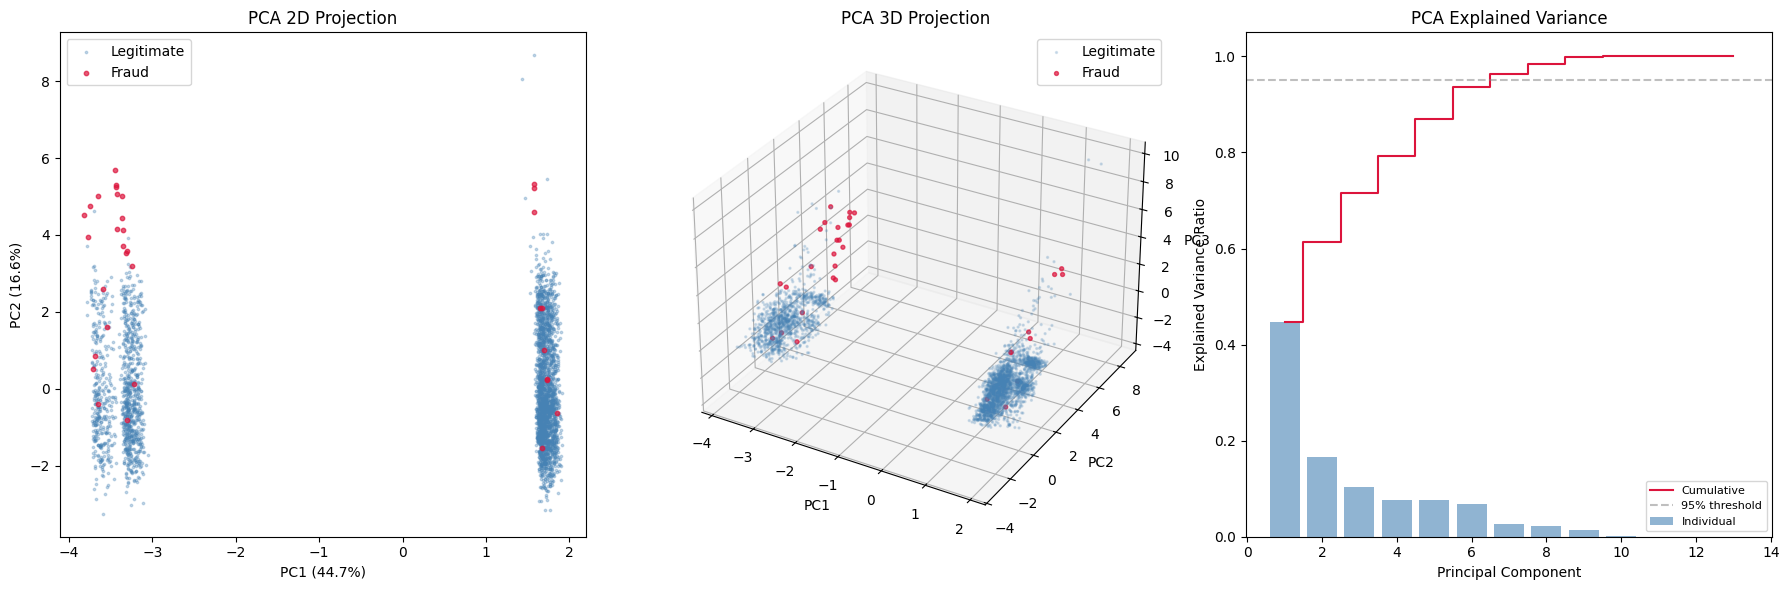


Total explained variance (2 components): 61.28%
Total explained variance (3 components): 71.57%
Components needed for 95% variance: 7


In [ ]:
# ============================================================
# 10b. PCA — 2D and 3D Projections (Fraud vs Legitimate)
# ============================================================
features_for_pca = ['amt', 'log_amt', 'lat', 'long', 'city_pop', 'merch_lat',
                    'merch_long', 'hour', 'day_of_week', 'age', 'distance_km',
                    'category_enc', 'unix_time']

X = adults[features_for_pca].dropna()
y = adults.loc[X.index, 'is_fraud']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2D PCA
pca_2d = PCA(n_components=2)
X_pca2 = pca_2d.fit_transform(X_scaled)

# 3D PCA
pca_3d = PCA(n_components=3)
X_pca3 = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(18, 6))

# 2D scatter
ax1 = fig.add_subplot(1, 3, 1)
mask_leg = y == 0
mask_fr = y == 1
ax1.scatter(X_pca2[mask_leg, 0], X_pca2[mask_leg, 1], s=3, alpha=0.3,
            c='steelblue', label='Legitimate')
ax1.scatter(X_pca2[mask_fr, 0], X_pca2[mask_fr, 1], s=10, alpha=0.7,
            c='crimson', label='Fraud', zorder=5)
ax1.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
ax1.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
ax1.set_title('PCA 2D Projection')
ax1.legend()

# 3D scatter
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
ax2.scatter(X_pca3[mask_leg, 0], X_pca3[mask_leg, 1], X_pca3[mask_leg, 2],
            s=2, alpha=0.2, c='steelblue', label='Legitimate')
ax2.scatter(X_pca3[mask_fr, 0], X_pca3[mask_fr, 1], X_pca3[mask_fr, 2],
            s=8, alpha=0.7, c='crimson', label='Fraud')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_zlabel('PC3')
ax2.set_title('PCA 3D Projection')
ax2.legend()

# Explained variance
ax3 = fig.add_subplot(1, 3, 3)
pca_full = PCA().fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
ax3.bar(range(1, len(cumvar) + 1), pca_full.explained_variance_ratio_,
        alpha=0.6, color='steelblue', label='Individual')
ax3.step(range(1, len(cumvar) + 1), cumvar, where='mid',
         color='crimson', label='Cumulative')
ax3.axhline(y=0.95, color='grey', linestyle='--', alpha=0.5, label='95% threshold')
ax3.set_xlabel('Principal Component')
ax3.set_ylabel('Explained Variance Ratio')
ax3.set_title('PCA Explained Variance')
ax3.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nTotal explained variance (2 components): {pca_2d.explained_variance_ratio_.sum():.2%}")
print(f"Total explained variance (3 components): {pca_3d.explained_variance_ratio_.sum():.2%}")
n_95 = np.argmax(cumvar >= 0.95) + 1
print(f"Components needed for 95% variance: {n_95}")

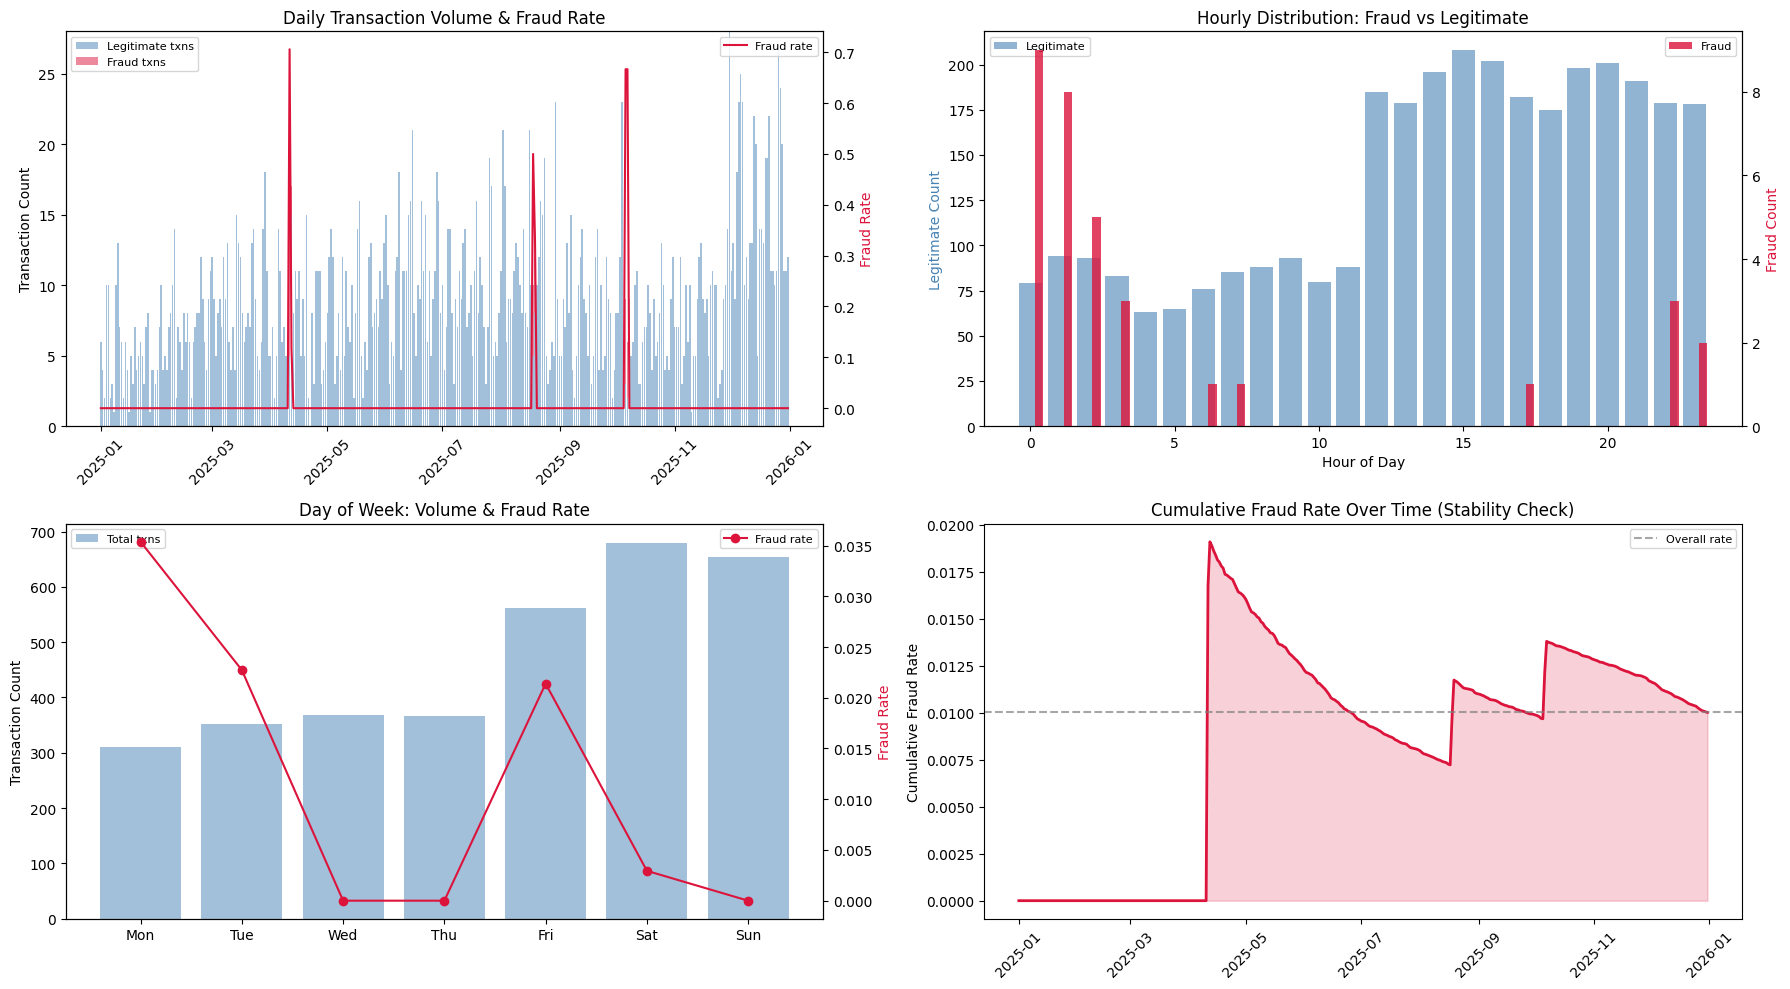

In [ ]:
# ============================================================
# 10c. Fraud Rate Over Time vs Legitimate Transaction Volume
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# --- Daily fraud rate vs legitimate volume ---
daily = adults.groupby('trans_date').agg(
    total=('is_fraud', 'count'),
    fraud=('is_fraud', 'sum')
).reset_index()
daily['legit'] = daily['total'] - daily['fraud']
daily['fraud_rate'] = daily['fraud'] / daily['total']

ax = axes[0, 0]
ax2_twin = ax.twinx()
ax.bar(daily['trans_date'], daily['legit'], color='steelblue', alpha=0.5, label='Legitimate txns')
ax.bar(daily['trans_date'], daily['fraud'], bottom=daily['legit'], color='crimson', alpha=0.5, label='Fraud txns')
ax2_twin.plot(daily['trans_date'], daily['fraud_rate'], color='crimson', linewidth=1.5, label='Fraud rate')
ax.set_ylabel('Transaction Count')
ax2_twin.set_ylabel('Fraud Rate', color='crimson')
ax.set_title('Daily Transaction Volume & Fraud Rate')
ax.legend(loc='upper left', fontsize=8)
ax2_twin.legend(loc='upper right', fontsize=8)
ax.tick_params(axis='x', rotation=45)

# --- Hourly pattern: fraud count vs legitimate count ---
hourly = adults.groupby(['hour', 'is_fraud']).size().unstack(fill_value=0)
hourly.columns = ['Legitimate', 'Fraud']

ax = axes[0, 1]
ax.bar(hourly.index, hourly['Legitimate'], color='steelblue', alpha=0.6, label='Legitimate')
ax_twin2 = ax.twinx()
ax_twin2.bar(hourly.index + 0.3, hourly['Fraud'], width=0.3, color='crimson', alpha=0.8, label='Fraud')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Legitimate Count', color='steelblue')
ax_twin2.set_ylabel('Fraud Count', color='crimson')
ax.set_title('Hourly Distribution: Fraud vs Legitimate')
ax.legend(loc='upper left', fontsize=8)
ax_twin2.legend(loc='upper right', fontsize=8)

# --- Day of week pattern ---
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_fraud_rate = adults.groupby('day_of_week')['is_fraud'].mean()
dow_total = adults.groupby('day_of_week').size()

ax = axes[1, 0]
ax_twin3 = ax.twinx()
ax.bar(dow_fraud_rate.index, dow_total.values, color='steelblue', alpha=0.5, label='Total txns')
ax_twin3.plot(dow_fraud_rate.index, dow_fraud_rate.values, 'o-', color='crimson', label='Fraud rate')
ax.set_xticks(range(7))
ax.set_xticklabels(dow_labels)
ax.set_ylabel('Transaction Count')
ax_twin3.set_ylabel('Fraud Rate', color='crimson')
ax.set_title('Day of Week: Volume & Fraud Rate')
ax.legend(loc='upper left', fontsize=8)
ax_twin3.legend(loc='upper right', fontsize=8)

# --- Cumulative fraud over time ---
daily_sorted = daily.sort_values('trans_date')
daily_sorted['cum_fraud'] = daily_sorted['fraud'].cumsum()
daily_sorted['cum_total'] = daily_sorted['total'].cumsum()
daily_sorted['cum_fraud_rate'] = daily_sorted['cum_fraud'] / daily_sorted['cum_total']

ax = axes[1, 1]
ax.plot(daily_sorted['trans_date'], daily_sorted['cum_fraud_rate'], color='crimson', linewidth=2)
ax.fill_between(daily_sorted['trans_date'], daily_sorted['cum_fraud_rate'],
                alpha=0.2, color='crimson')
ax.set_ylabel('Cumulative Fraud Rate')
ax.set_title('Cumulative Fraud Rate Over Time (Stability Check)')
ax.tick_params(axis='x', rotation=45)
ax.axhline(y=adults['is_fraud'].mean(), color='grey', linestyle='--', alpha=0.7, label='Overall rate')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

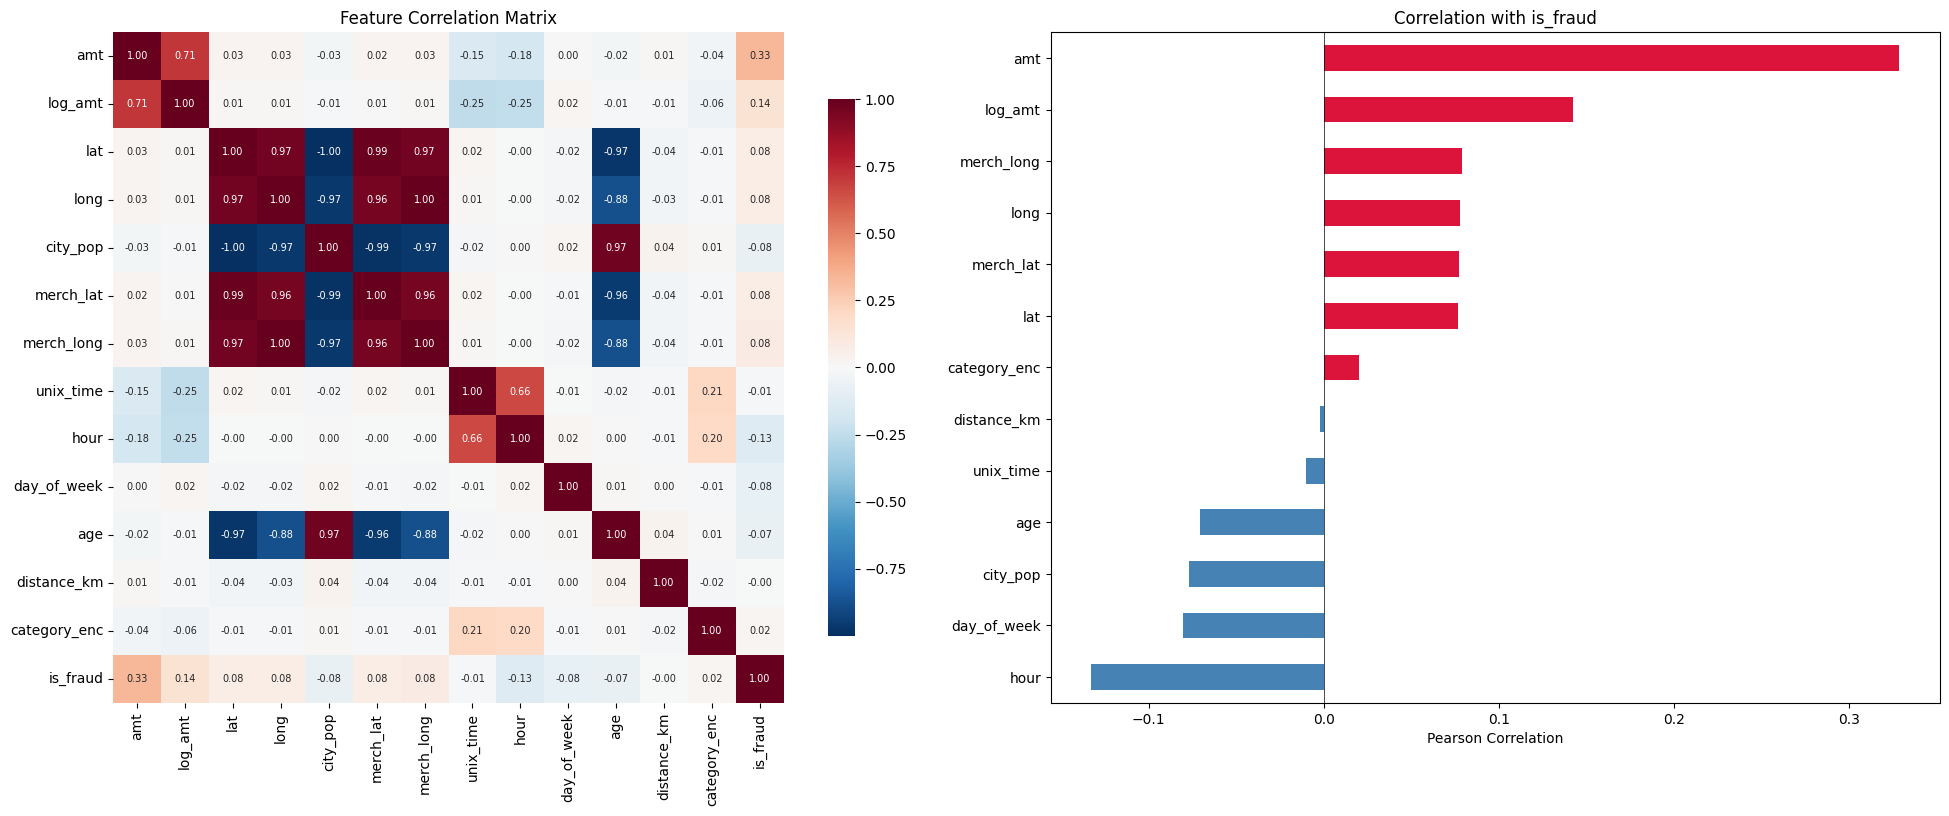


Top features correlated with fraud (absolute):
amt             0.328597
log_amt         0.142561
hour            0.132809
day_of_week     0.080509
merch_long      0.079228
long            0.077905
merch_lat       0.077488
city_pop        0.076689
lat             0.076657
age             0.070703
category_enc    0.020054
unix_time       0.010239
distance_km     0.001978


In [ ]:
# ============================================================
# 10d. Correlation Heatmap of Numeric Features
# ============================================================
numeric_cols = ['amt', 'log_amt', 'lat', 'long', 'city_pop', 'merch_lat',
                'merch_long', 'unix_time', 'hour', 'day_of_week', 'age',
                'distance_km', 'category_enc', 'is_fraud']

corr = adults[numeric_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Full correlation matrix
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=axes[0], cbar_kws={'shrink': 0.8},
            annot_kws={'size': 7})
axes[0].set_title('Feature Correlation Matrix')

# Correlation with target (is_fraud) only
fraud_corr = corr['is_fraud'].drop('is_fraud').sort_values()
colors = ['crimson' if v > 0 else 'steelblue' for v in fraud_corr.values]
fraud_corr.plot.barh(ax=axes[1], color=colors)
axes[1].set_title('Correlation with is_fraud')
axes[1].set_xlabel('Pearson Correlation')
axes[1].axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

print("\nTop features correlated with fraud (absolute):")
print(fraud_corr.abs().sort_values(ascending=False).to_string())

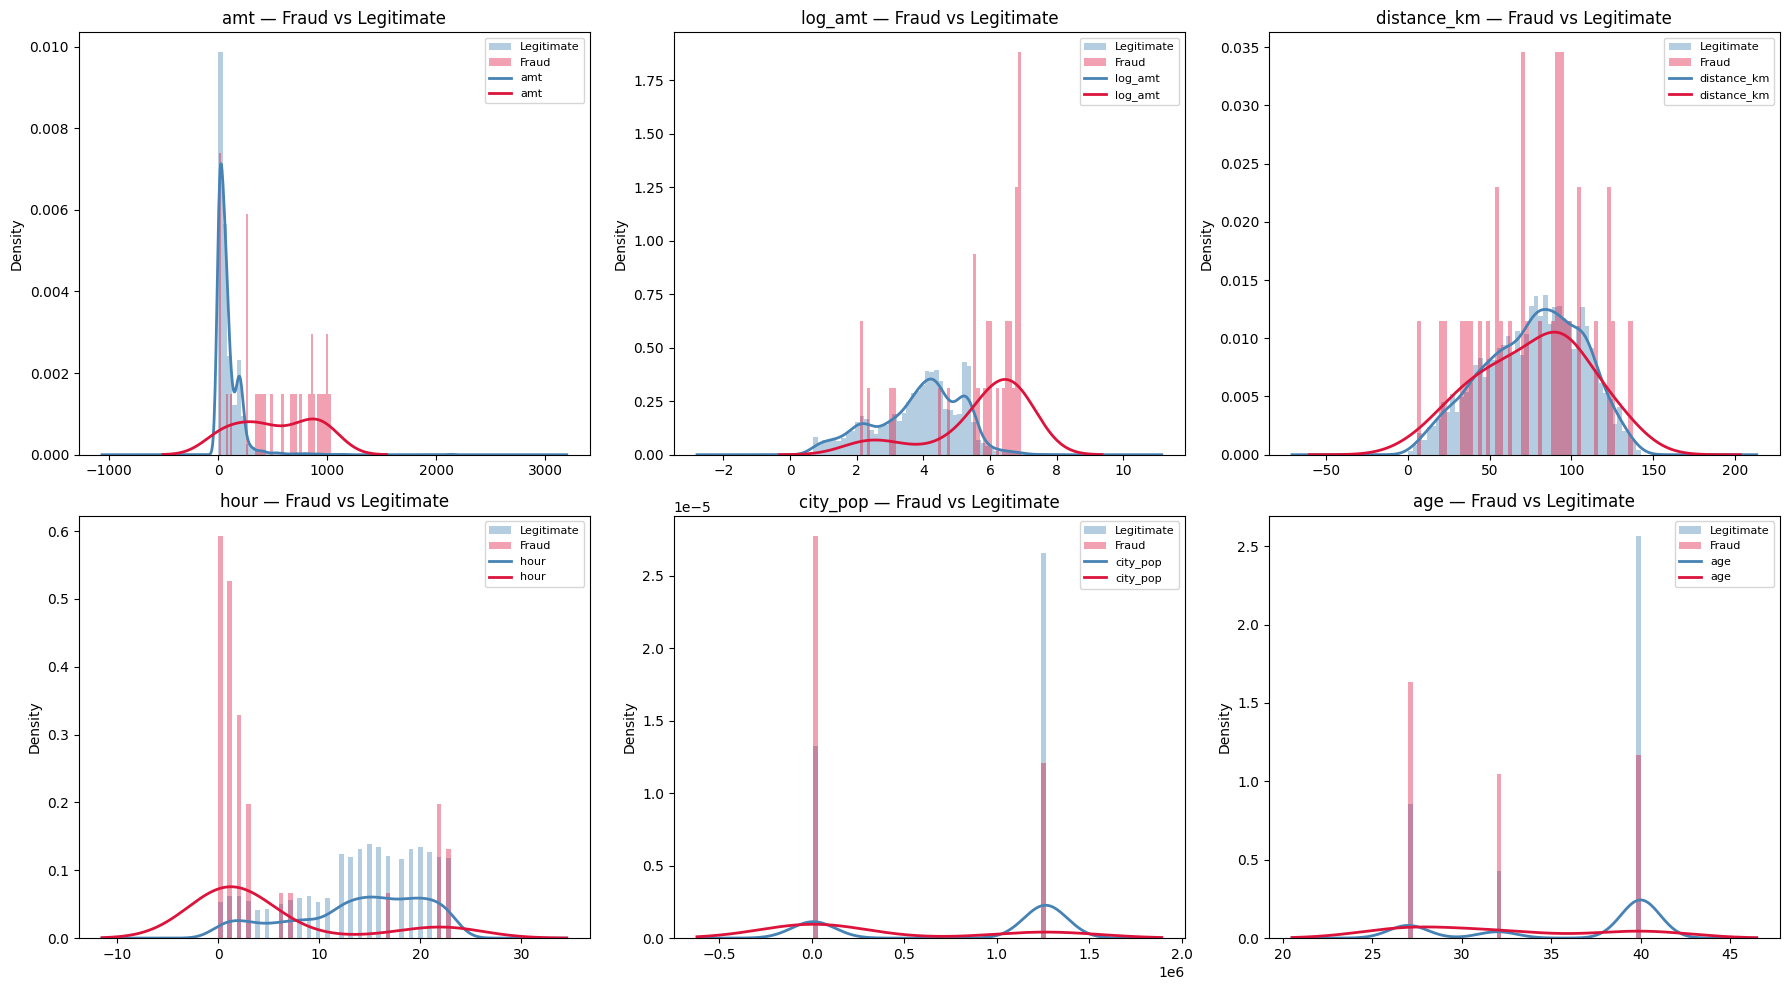

In [ ]:
# ============================================================
# 10e. Feature Distributions — Fraud vs Legitimate (KDE Plots)
# ============================================================
plot_features = ['amt', 'log_amt', 'distance_km', 'hour', 'city_pop', 'age']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(plot_features):
    ax = axes[i]
    data_leg = adults.loc[adults['is_fraud'] == 0, feat].dropna()
    data_fr = adults.loc[adults['is_fraud'] == 1, feat].dropna()
    
    ax.hist(data_leg, bins=50, density=True, alpha=0.4, color='steelblue', label='Legitimate')
    ax.hist(data_fr, bins=50, density=True, alpha=0.4, color='crimson', label='Fraud')
    
    # KDE overlay
    if len(data_leg) > 1 and len(data_fr) > 1:
        try:
            data_leg.plot.kde(ax=ax, color='steelblue', linewidth=2)
            data_fr.plot.kde(ax=ax, color='crimson', linewidth=2)
        except Exception:
            pass
    
    ax.set_title(f'{feat} — Fraud vs Legitimate')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

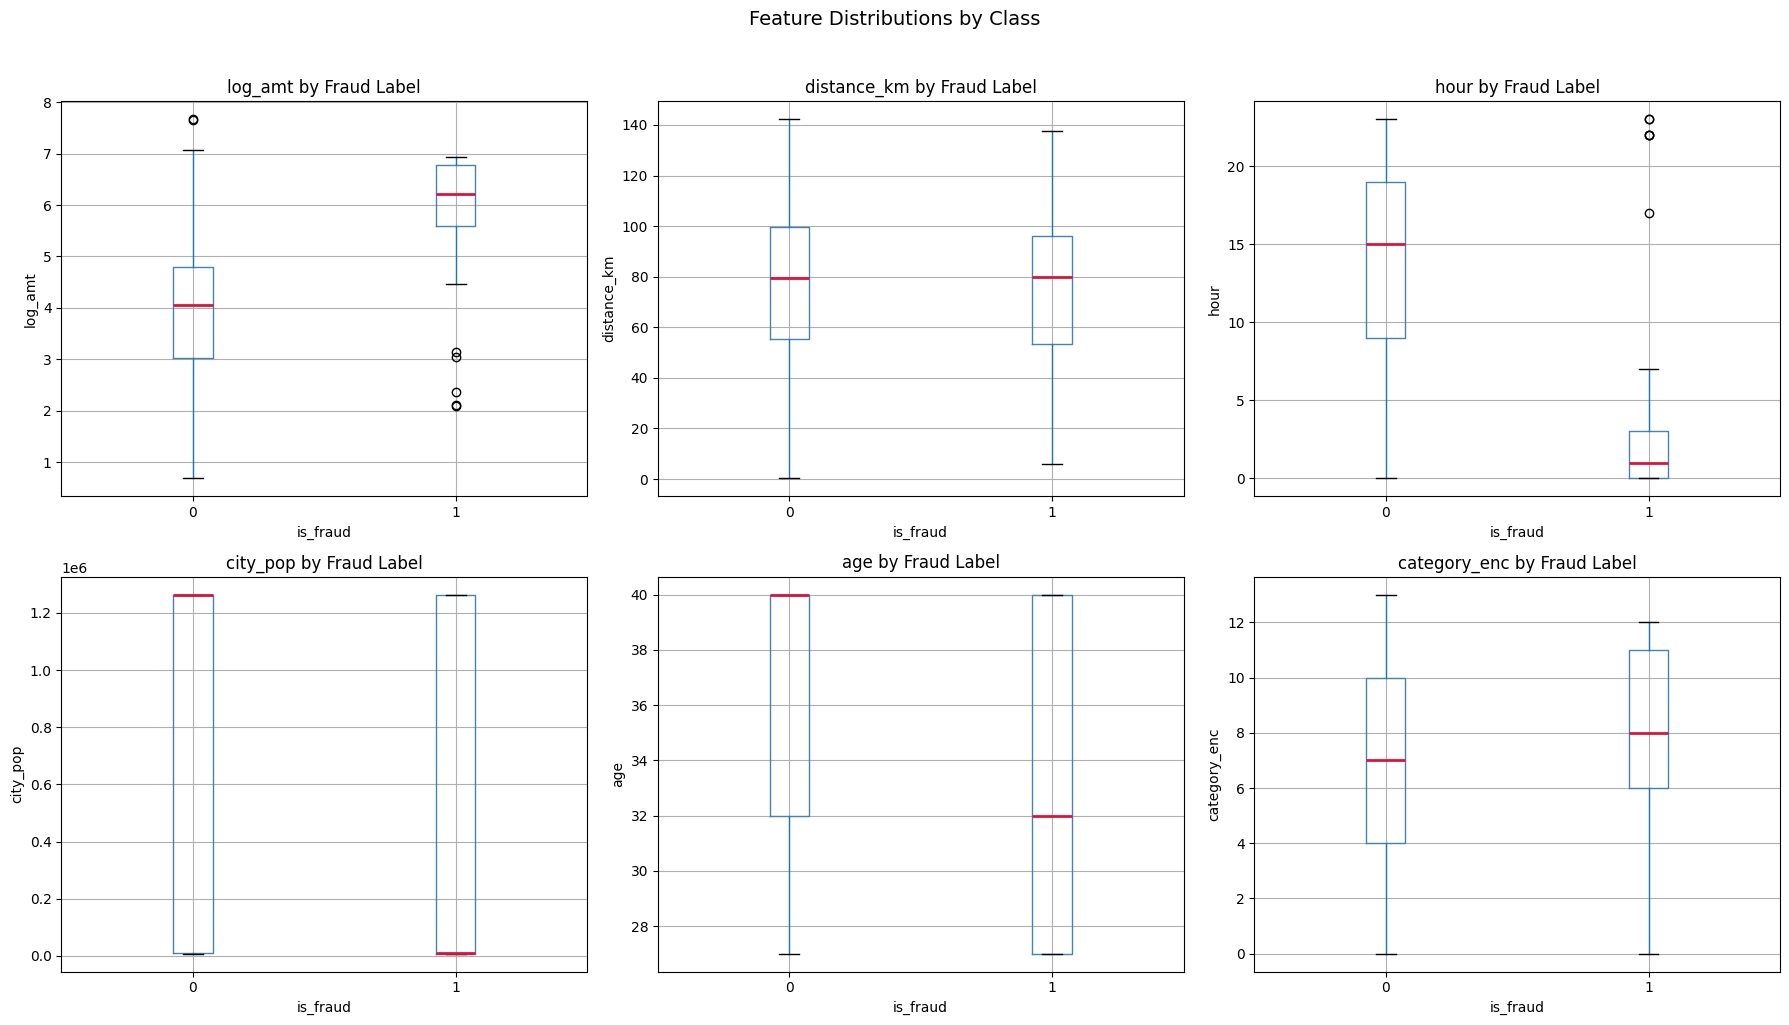

In [ ]:
# ============================================================
# 10f. Class Separability — Box Plots by Fraud Label
# ============================================================
box_features = ['log_amt', 'distance_km', 'hour', 'city_pop', 'age', 'category_enc']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(box_features):
    ax = axes[i]
    adults.boxplot(column=feat, by='is_fraud', ax=ax,
                   boxprops=dict(color='steelblue'),
                   medianprops=dict(color='crimson', linewidth=2))
    ax.set_title(f'{feat} by Fraud Label')
    ax.set_xlabel('is_fraud')
    ax.set_ylabel(feat)

plt.suptitle('Feature Distributions by Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

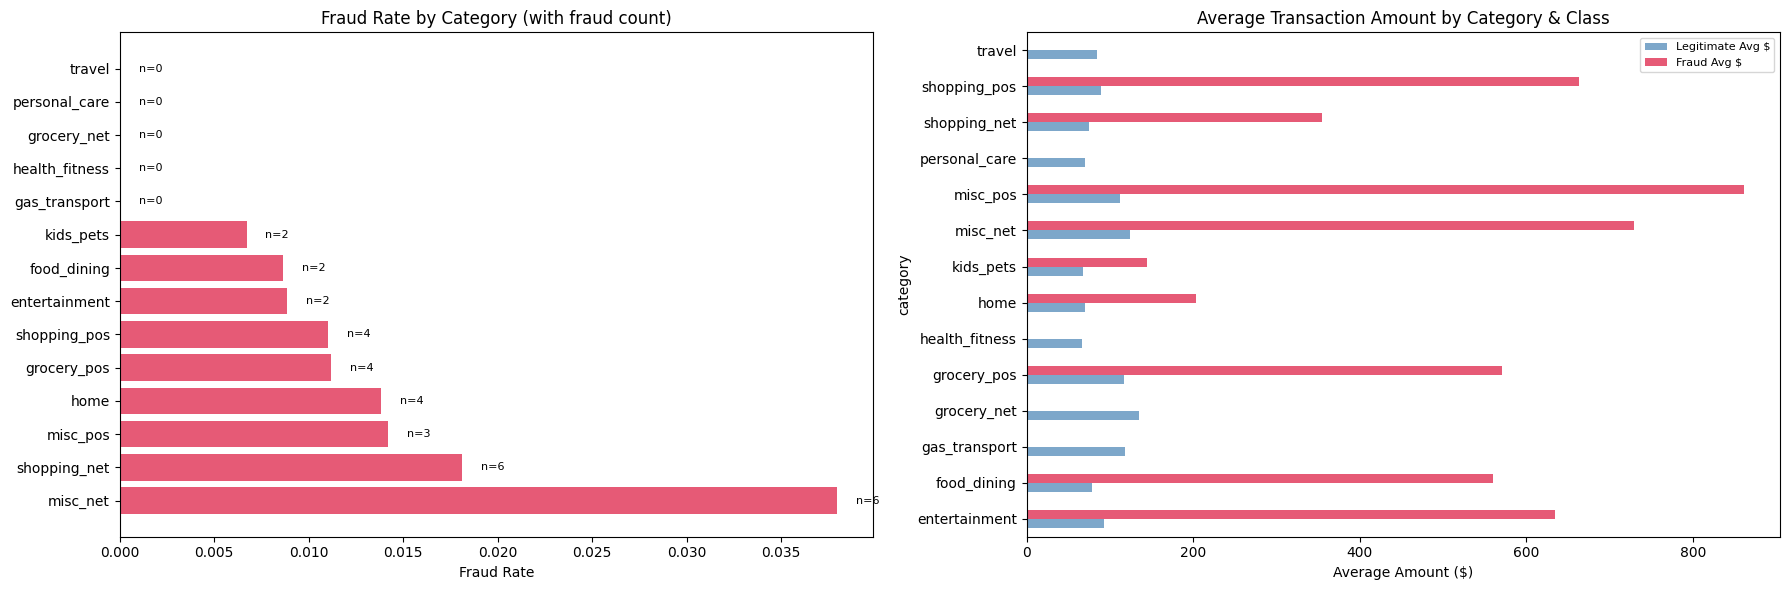

In [ ]:
# ============================================================
# 10g. Fraud by Category — Heatmap & Rate Analysis
# ============================================================
cat_fraud = adults.groupby('category').agg(
    total=('is_fraud', 'count'),
    fraud=('is_fraud', 'sum'),
    fraud_rate=('is_fraud', 'mean'),
    avg_amt=('amt', 'mean'),
    avg_fraud_amt=('amt', lambda x: adults.loc[x.index[adults.loc[x.index, 'is_fraud'] == 1], 'amt'].mean() if (adults.loc[x.index, 'is_fraud'] == 1).any() else 0)
).sort_values('fraud_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Category fraud rate with count annotation
ax = axes[0]
bars = ax.barh(cat_fraud.index, cat_fraud['fraud_rate'], color='crimson', alpha=0.7)
for bar, count in zip(bars, cat_fraud['fraud']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'n={int(count)}', va='center', fontsize=8)
ax.set_title('Fraud Rate by Category (with fraud count)')
ax.set_xlabel('Fraud Rate')

# Average amount: fraud vs legit by category
cat_amt = adults.groupby(['category', 'is_fraud'])['amt'].mean().unstack(fill_value=0)
cat_amt.columns = ['Legitimate Avg $', 'Fraud Avg $']
cat_amt.plot.barh(ax=axes[1], color=['steelblue', 'crimson'], alpha=0.7)
axes[1].set_title('Average Transaction Amount by Category & Class')
axes[1].set_xlabel('Average Amount ($)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

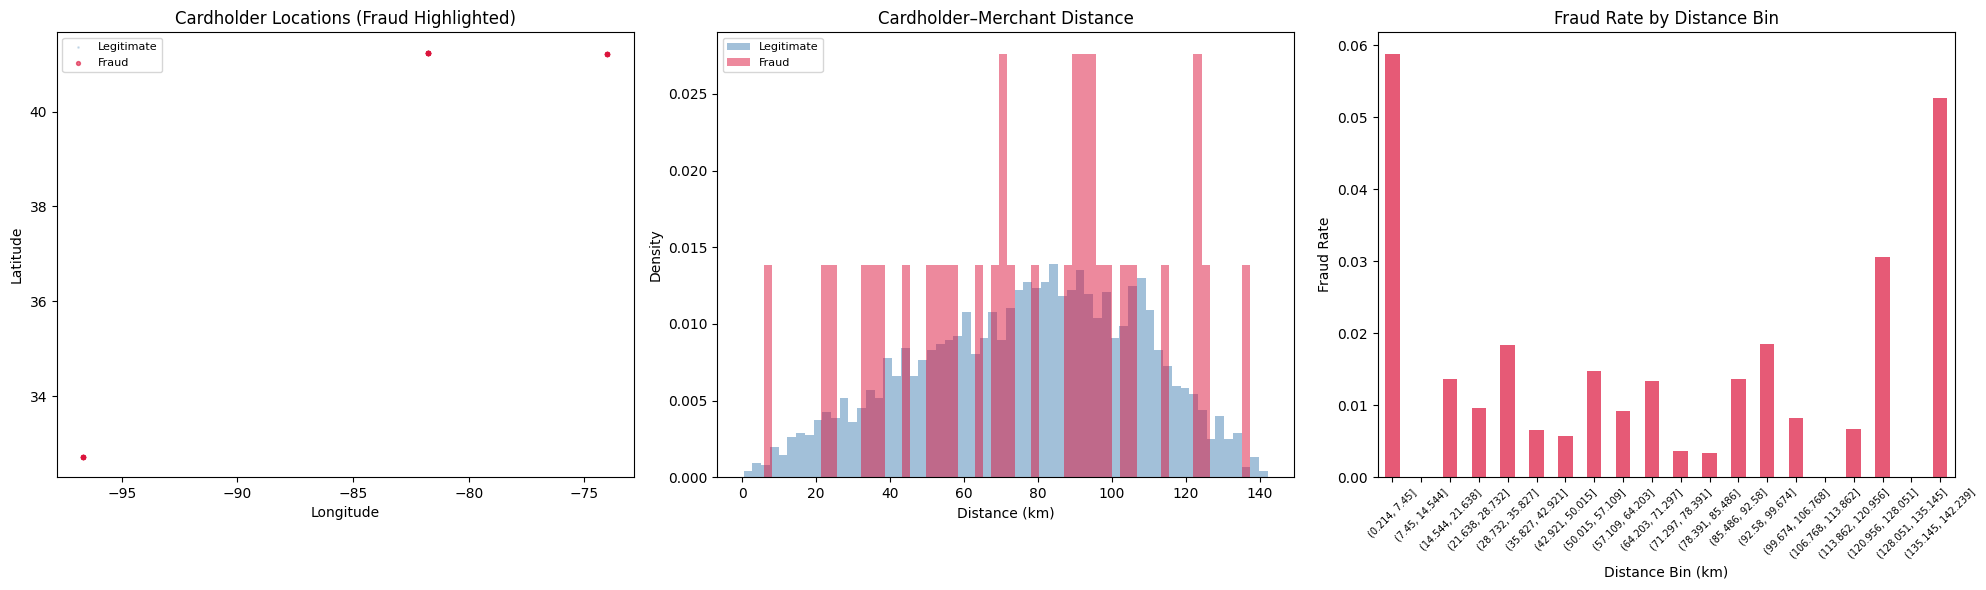

In [ ]:
# ============================================================
# 10h. Geographic Analysis — Fraud Hotspots
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Cardholder locations colored by fraud
ax = axes[0]
ax.scatter(adults.loc[adults['is_fraud'] == 0, 'long'],
           adults.loc[adults['is_fraud'] == 0, 'lat'],
           s=1, alpha=0.2, c='steelblue', label='Legitimate')
ax.scatter(adults.loc[adults['is_fraud'] == 1, 'long'],
           adults.loc[adults['is_fraud'] == 1, 'lat'],
           s=8, alpha=0.6, c='crimson', label='Fraud', zorder=5)
ax.set_title('Cardholder Locations (Fraud Highlighted)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(fontsize=8)

# Merchant-cardholder distance distribution
ax = axes[1]
ax.hist(adults.loc[adults['is_fraud'] == 0, 'distance_km'], bins=60, density=True,
        alpha=0.5, color='steelblue', label='Legitimate')
ax.hist(adults.loc[adults['is_fraud'] == 1, 'distance_km'], bins=60, density=True,
        alpha=0.5, color='crimson', label='Fraud')
ax.set_title('Cardholder–Merchant Distance')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Density')
ax.legend(fontsize=8)

# Fraud rate by distance bin
adults['dist_bin'] = pd.cut(adults['distance_km'], bins=20)
dist_fraud = adults.groupby('dist_bin', observed=True)['is_fraud'].mean()
ax = axes[2]
dist_fraud.plot.bar(ax=ax, color='crimson', alpha=0.7)
ax.set_title('Fraud Rate by Distance Bin')
ax.set_xlabel('Distance Bin (km)')
ax.set_ylabel('Fraud Rate')
ax.tick_params(axis='x', rotation=45, labelsize=7)

plt.tight_layout()
plt.show()

adults.drop(columns=['dist_bin'], inplace=True)

ML READINESS ASSESSMENT

Dataset size:    3,294 samples
Features:        13
Class balance:   {0: 3261, 1: 33}
Fraud ratio:     1.0018%
Missing values:  0

--- Quick Random Forest Baseline (3-fold CV) ---
  Fold 1: AUC-ROC = 0.9967
  Fold 2: AUC-ROC = 0.9447
  Fold 3: AUC-ROC = 0.9402
  Mean AUC-ROC: 0.9605 (+/- 0.0256)


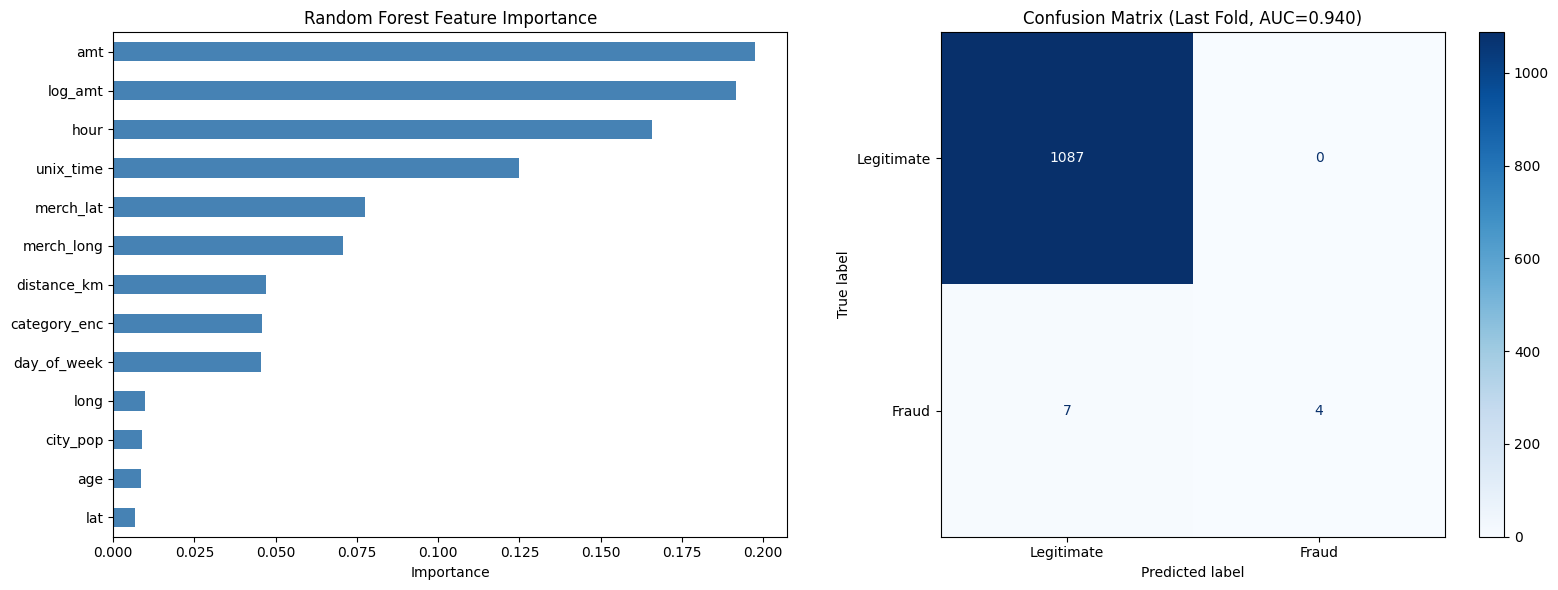


VERDICT
AUC-ROC 0.960 — Strong signal for ML training.
Fraud rate 1.0018% — Moderately imbalanced. Class weighting recommended.


In [ ]:
# ============================================================
# 10i. ML Readiness Summary — Statistical Tests & Baseline
# ============================================================
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

features_ml = ['amt', 'log_amt', 'lat', 'long', 'city_pop', 'merch_lat',
               'merch_long', 'unix_time', 'hour', 'day_of_week', 'age',
               'distance_km', 'category_enc']

X_ml = adults[features_ml].dropna()
y_ml = adults.loc[X_ml.index, 'is_fraud']

print("="*60)
print("ML READINESS ASSESSMENT")
print("="*60)
print(f"\nDataset size:    {len(X_ml):,} samples")
print(f"Features:        {len(features_ml)}")
print(f"Class balance:   {y_ml.value_counts().to_dict()}")
print(f"Fraud ratio:     {y_ml.mean():.4%}")
print(f"Missing values:  {X_ml.isnull().sum().sum()}")

# Quick Random Forest baseline (3-fold stratified CV)
print("\n--- Quick Random Forest Baseline (3-fold CV) ---")
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
auc_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_ml, y_ml)):
    rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X_ml.iloc[train_idx], y_ml.iloc[train_idx])
    y_prob = rf.predict_proba(X_ml.iloc[val_idx])[:, 1]
    auc = roc_auc_score(y_ml.iloc[val_idx], y_prob)
    auc_scores.append(auc)
    print(f"  Fold {fold+1}: AUC-ROC = {auc:.4f}")

print(f"  Mean AUC-ROC: {np.mean(auc_scores):.4f} (+/- {np.std(auc_scores):.4f})")

# Final model on full data for feature importance & confusion matrix
rf_full = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_full.fit(X_ml, y_ml)

# Feature importance
importances = pd.Series(rf_full.feature_importances_, index=features_ml).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

importances.plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Random Forest Feature Importance')
axes[0].set_xlabel('Importance')

# Confusion matrix from last fold
y_pred = rf.predict(X_ml.iloc[val_idx])
cm = confusion_matrix(y_ml.iloc[val_idx], y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Fraud']).plot(ax=axes[1], cmap='Blues')
axes[1].set_title(f'Confusion Matrix (Last Fold, AUC={auc_scores[-1]:.3f})')

plt.tight_layout()
plt.show()

# Final verdict
print("\n" + "="*60)
print("VERDICT")
print("="*60)
if np.mean(auc_scores) > 0.85:
    print(f"AUC-ROC {np.mean(auc_scores):.3f} — Strong signal for ML training.")
elif np.mean(auc_scores) > 0.70:
    print(f"AUC-ROC {np.mean(auc_scores):.3f} — Moderate signal, ML feasible with tuning.")
else:
    print(f"AUC-ROC {np.mean(auc_scores):.3f} — Weak signal, may need more features or data.")

if y_ml.mean() < 0.01:
    print(f"Fraud rate {y_ml.mean():.4%} — Very imbalanced. Use SMOTE/class weights/focal loss.")
elif y_ml.mean() < 0.05:
    print(f"Fraud rate {y_ml.mean():.4%} — Moderately imbalanced. Class weighting recommended.")
else:
    print(f"Fraud rate {y_ml.mean():.4%} — Reasonable balance for training.")